# CMM704 Data Mining : Question 1 Regression with MLP
#### Fouzul Hassan
##### RGU No : 2410544 / IIT No : 20233214

## Data loading


In [ ]:
import pandas as pd

df = pd.read_csv('ds_salaries.csv')
display(df.head())
print(df.shape)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000.0,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000.0,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500.0,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000.0,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000.0,USD,120000,CA,100,CA,M


(3755, 11)


## Data exploration



## Data cleaning



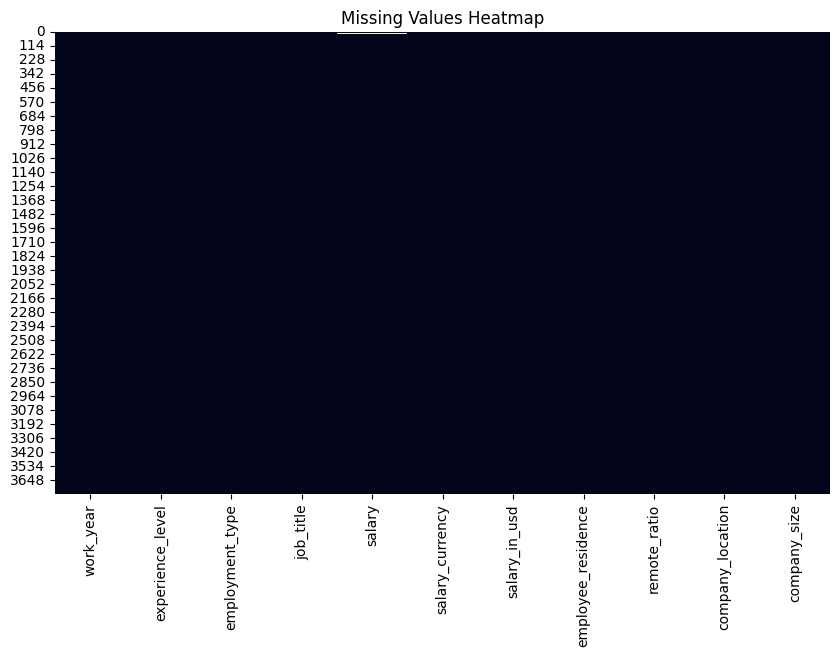

In [ ]:
#heatmap for missing value percentage
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
df = df.drop_duplicates()
print(df.shape)

(2588, 11)


In [ ]:
#number of missing values
missing_values = df.isnull().sum()
print(missing_values)

work_year             0
experience_level      3
employment_type       3
job_title             5
salary                4
salary_currency       0
salary_in_usd         0
employee_residence    1
remote_ratio          0
company_location      0
company_size          0
dtype: int64


In [ ]:
#percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

work_year             0.000000
experience_level      0.115920
employment_type       0.115920
job_title             0.193199
salary                0.154560
salary_currency       0.000000
salary_in_usd         0.000000
employee_residence    0.038640
remote_ratio          0.000000
company_location      0.000000
company_size          0.000000
dtype: float64


In [ ]:
df.isnull().corr().round(4)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
work_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_level,NaN,1.0000,-0.0012,-0.0015,-0.0013,NaN,NaN,-0.0007,NaN,NaN,NaN
employment_type,NaN,-0.0012,1.0000,-0.0015,-0.0013,NaN,NaN,-0.0007,NaN,NaN,NaN
job_title,NaN,-0.0015,-0.0015,1.0000,-0.0017,NaN,NaN,-0.0009,NaN,NaN,NaN
salary,NaN,-0.0013,-0.0013,-0.0017,1.0000,NaN,NaN,-0.0008,NaN,NaN,NaN
salary_currency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employee_residence,NaN,-0.0007,-0.0007,-0.0009,-0.0008,NaN,NaN,1.0000,NaN,NaN,NaN
remote_ratio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_location,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


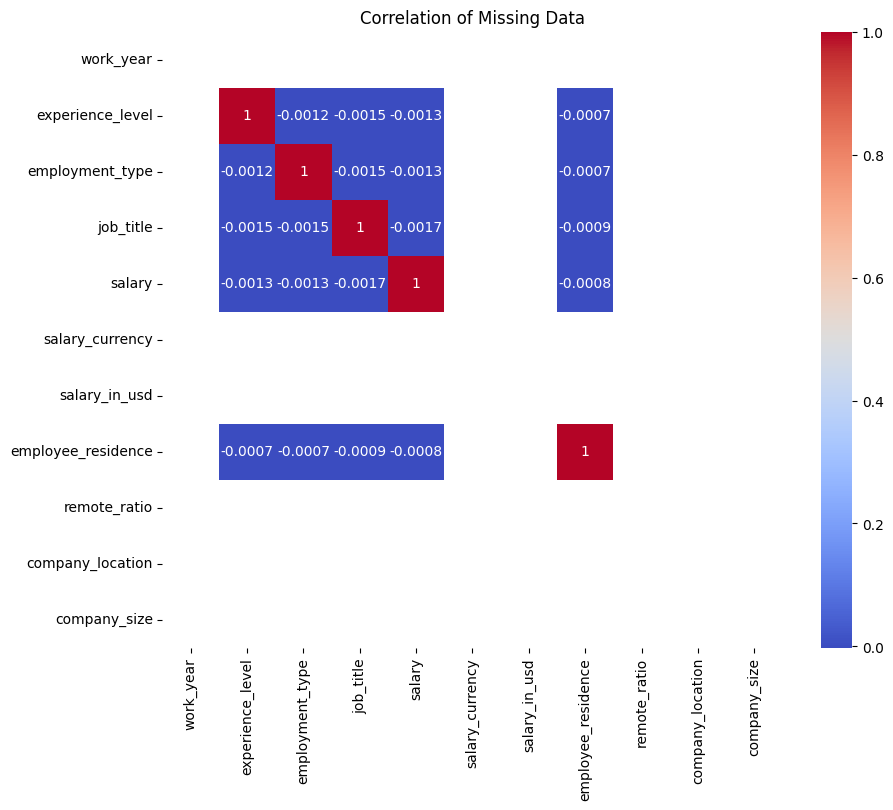

In [ ]:
corr_matrix = df.isnull().corr().round(4)
#increase the correlation box size
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation of Missing Data")
plt.show()

In [ ]:
# Keep only rows where experience_level is null
df_missing_experience = df[df["experience_level"].isnull()]
df_missing_experience

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
98,2023,NaN,FT,Data Engineer,185000.0,USD,185000,US,100,US,M
106,2023,NaN,FT,Data Engineer,94300.0,USD,94300,US,0,US,M
118,2023,NaN,FT,Analytics Engineer,214000.0,USD,214000,US,0,US,M


In [ ]:
# Keep only rows where employment_type is null
df_missing_employment_type = df[df["employment_type"].isnull()]
df_missing_employment_type

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
93,2023,SE,NaN,Data Scientist,105000.0,USD,105000,US,0,US,M
354,2023,SE,NaN,Data Scientist,185900.0,USD,185900,US,0,US,M
358,2023,SE,NaN,Machine Learning Engineer,304000.0,USD,304000,US,100,US,M


In [ ]:
# Keep only rows where job_title is null
df_missing_job_title = df[df["job_title"].isnull()]
df_missing_job_title

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
23,2023,SE,FT,NaN,230000.0,USD,230000,GB,100,GB,M
60,2023,SE,FT,NaN,231500.0,USD,231500,US,100,US,M
71,2023,SE,FT,NaN,81500.0,USD,81500,US,0,US,M
110,2023,SE,FT,NaN,133800.0,USD,133800,US,0,US,M
360,2023,MI,FT,NaN,45000.0,EUR,48289,ES,100,ES,M


In [ ]:
# Keep only rows where salary is null
df_missing_salary = df[df["salary"].isnull()]
df_missing_salary

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
16,2023,SE,FT,Data Modeler,NaN,USD,90700,US,0,US,M
41,2022,MI,FT,Machine Learning Engineer,NaN,INR,20984,IN,50,IN,L
364,2023,SE,FT,Data Scientist,NaN,USD,110000,US,100,US,M
376,2023,SE,FT,Data Analytics Manager,NaN,USD,120000,US,100,US,M


In [ ]:
# Keep only rows where salary is null
df_missing_employee_residence = df[df["employee_residence"].isnull()]
df_missing_employee_residence

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
29,2023,SE,FT,Data Strategist,90000.0,USD,90000,NaN,0,CA,M


### Handeling Missing Values

In [ ]:
df.shape

(2588, 11)

employee_residence is has missing value less than 5%, it is a categorical variale, therefore imputing with mode

In [ ]:
#impute employee residence with mode
df['employee_residence'].fillna(df['employee_residence'].mode()[0], inplace=True)

# verify employee residence doesnt have any missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
work_year             0
experience_level      3
employment_type       3
job_title             5
salary                4
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


<ipython-input-6-fa20c26729ef>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['employee_residence'].fillna(df['employee_residence'].mode()[0], inplace=True)


experience_level,employment_type,job_title, salary are contains missing values 5-20%, therefore considering KNN imputation

In [ ]:
#knn imputation for experience_level,employment_type,job_title, salary
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

# Columns with missing values
missing_columns = ["experience_level", "employment_type", "job_title", "salary"]

# Encode categorical columns to numerical values
label_encoders = {}

for col in ["experience_level", "employment_type", "job_title", "salary_currency", "employee_residence", "company_location", "company_size"]: # Include all your categorical features here
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = df[col].replace("nan", np.nan)
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Apply KNN Imputation
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Convert categorical columns back to original labels
for col in ["experience_level", "employment_type", "job_title", "salary_currency", "employee_residence", "company_location", "company_size"]: # Include all your categorical features here
    df_imputed[col] = df_imputed[col].round().astype(int)
    df_imputed[col] = label_encoders[col].inverse_transform(df_imputed[col])

df = df_imputed

In [ ]:
# Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


#Data Preprocessing

In [ ]:
#drop 'nan'
df = df[df['experience_level'] != 'nan']

In [ ]:
#drop 'nan'
df = df[df['employment_type'] != 'nan']

In [ ]:
#drop 'nan'
df = df[df['job_title'] != 'nan']

In [ ]:
pd.set_option('display.max_rows', 100)

job_title_counts = df['job_title'].value_counts(dropna=False)
job_title_percentages = (job_title_counts / len(df)) * 100
job_title_summary = pd.DataFrame({
    'Count': job_title_counts,
    'Percentage': job_title_percentages.round(2)
})
job_title_summary = job_title_summary.sort_values(by='Count', ascending=False)

# Display
print(f"Total Unique Job Titles: {job_title_summary.shape[0]}")
print(job_title_summary)


Total Unique Job Titles: 93
                                          Count  Percentage
job_title                                                  
Data Engineer                               594       23.05
Data Scientist                              539       20.92
Data Analyst                                396       15.37
Machine Learning Engineer                   205        7.95
Analytics Engineer                           89        3.45
Research Scientist                           65        2.52
Data Architect                               64        2.48
Data Science Manager                         52        2.02
ML Engineer                                  34        1.32
Research Engineer                            33        1.28
Applied Scientist                            31        1.20
Machine Learning Scientist                   26        1.01
Data Manager                                 23        0.89
Data Science Consultant                      23        0.89
Computer Vis

In [ ]:
# Job title mapping
job_title_mapping = {
    # Data Scientist Related
    'Data Scientist': 'Data Scientist',
    'Applied Data Scientist': 'Data Scientist',
    'Research Scientist': 'Data Scientist',
    'Machine Learning Scientist': 'Data Scientist',
    'Staff Data Scientist': 'Data Scientist',
    'Lead Data Scientist': 'Data Scientist',
    'Product Data Scientist': 'Data Scientist',
    'Data Science Consultant': 'Data Scientist',
    'Data Science Engineer': 'Data Scientist',
    'Principal Data Scientist': 'Data Scientist',
    'Data Science Lead': 'Data Scientist',
    'Data Science Tech Lead': 'Data Scientist',

    # Data Engineer Related
    'Data Engineer': 'Data Engineer',
    'Cloud Data Engineer': 'Data Engineer',
    'Software Data Engineer': 'Data Engineer',
    'ETL Developer': 'Data Engineer',
    'ETL Engineer': 'Data Engineer',
    'Data Infrastructure Engineer': 'Data Engineer',
    'Data Operations Engineer': 'Data Engineer',
    'BI Data Engineer': 'Data Engineer',
    'Azure Data Engineer': 'Data Engineer',

    # Data Analyst Related
    'Data Analyst': 'Data Analyst',
    'BI Analyst': 'Data Analyst',
    'BI Data Analyst': 'Data Analyst',
    'Business Data Analyst': 'Data Analyst',
    'Compliance Data Analyst': 'Data Analyst',
    'Product Data Analyst': 'Data Analyst',
    'Financial Data Analyst': 'Data Analyst',
    'Staff Data Analyst': 'Data Analyst',
    'Insight Analyst': 'Data Analyst',

    # Machine Learning Engineers
    'Machine Learning Engineer': 'ML Engineer',
    'ML Engineer': 'ML Engineer',
    'Applied Machine Learning Engineer': 'ML Engineer',
    'Applied Machine Learning Scientist': 'ML Engineer',
    'Deep Learning Engineer': 'ML Engineer',
    'Deep Learning Researcher': 'ML Engineer',
    'Machine Learning Developer': 'ML Engineer',
    'NLP Engineer': 'ML Engineer',
    'Machine Learning Researcher': 'ML Engineer',
    'Machine Learning Research Engineer': 'ML Engineer',
    'Lead Machine Learning Engineer': 'ML Engineer',
    'Principal Machine Learning Engineer': 'ML Engineer',
    'Machine Learning Infrastructure Engineer': 'ML Engineer',
    'Machine Learning Software Engineer': 'ML Engineer',

    # Analytics Related
    'Analytics Engineer': 'Analytics',
    'Data Analytics Engineer': 'Analytics',
    'Data Analytics Lead': 'Analytics',
    'Data Analytics Manager': 'Analytics',
    'Data Analytics Consultant': 'Analytics',
    'Data Analytics Specialist': 'Analytics',

    # Architect Related
    'Data Architect': 'Architect',
    'Cloud Data Architect': 'Architect',
    'Principal Data Architect': 'Architect',
    'Big Data Architect': 'Architect',

    # Managerial Roles
    'Data Science Manager': 'Management',
    'Machine Learning Manager': 'Management',
    'Data Manager': 'Management',
    'Head of Data': 'Management',
    'Head of Data Science': 'Management',
    'Head of Machine Learning': 'Management',
    'Manager Data Management': 'Management',
    'Director of Data Science': 'Management',

    # AI Specialist Roles
    'AI Developer': 'AI Specialist',
    'AI Scientist': 'AI Specialist',
    'AI Programmer': 'AI Specialist',

    # Others
    'Computer Vision Engineer': 'Other',
    'Computer Vision Software Engineer': 'Other',
    '3D Computer Vision Researcher': 'Other',
    'Autonomous Vehicle Technician': 'Other',
    'Data Strategist': 'Other',
    'Data Operations Analyst': 'Other',
    'Cloud Database Engineer': 'Other',
    'Power BI Developer': 'Other',
    'Marketing Data Analyst': 'Other',
    'Marketing Data Engineer': 'Other',
    'Data Management Specialist': 'Other',
    'Big Data Engineer': 'Other',
    'Data Modeler': 'Other',
    'Finance Data Analyst': 'Other'
}

# Apply the mapping
df['job_title_grouped'] = df['job_title'].map(job_title_mapping)

# Fill unmapped jobs with 'Other'
df['job_title_grouped'] = df['job_title_grouped'].fillna('Other')


In [ ]:
pd.set_option('display.max_rows', 100)

job_title_counts = df['job_title_grouped'].value_counts(dropna=False)
job_title_percentages = (job_title_counts / len(df)) * 100
job_title_summary = pd.DataFrame({
    'Count': job_title_counts,
    'Percentage': job_title_percentages.round(2)
})
job_title_summary = job_title_summary.sort_values(by='Count', ascending=False)

# Display
print(f"Total Unique Job Titles: {job_title_summary.shape[0]}")
print(job_title_summary)


Total Unique Job Titles: 9
                   Count  Percentage
job_title_grouped                   
Data Scientist       696       27.01
Data Engineer        622       24.14
Data Analyst         447       17.35
ML Engineer          308       11.95
Other                178        6.91
Analytics            119        4.62
Management           110        4.27
Architect             68        2.64
AI Specialist         29        1.13


In [ ]:
geo_columns = ['employee_residence', 'company_location']

def group_rare_labels(df, col, threshold=10):
    value_counts = df[col].value_counts()
    rare_labels = value_counts[value_counts < threshold].index
    df[col] = df[col].apply(lambda x: 'Other' if x in rare_labels else x)
    return df

for col in geo_columns:
    df = group_rare_labels(df, col)

In [ ]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_title_grouped
0,2023.0,SE,FT,Principal Data Scientist,80000.0,EUR,85847.0,ES,100.0,ES,L,Data Scientist
1,2023.0,MI,CT,ML Engineer,30000.0,USD,30000.0,US,100.0,US,S,ML Engineer
2,2023.0,MI,CT,ML Engineer,25500.0,USD,25500.0,US,100.0,US,S,ML Engineer
3,2023.0,SE,FT,Data Scientist,175000.0,USD,175000.0,CA,100.0,CA,M,Data Scientist
4,2023.0,SE,FT,Data Scientist,120000.0,USD,120000.0,CA,100.0,CA,M,Data Scientist


## Data analysis

### Subtask:
Analyze the distribution of salary across different job titles, experience levels, employment types, and company sizes. Identify potential outliers in the salary variable.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import normaltest

# Set consistent plot style
sns.set_style("whitegrid")

# 1. Plot Univariate Distributions (Numeric)
def plot_numeric_distributions(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        plt.figure(figsize=(8, 4))
        sns.histplot(data=df, x=col, kde=True, bins=20)
        plt.title(f'{col} Distribution', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

        # Normality test
        stat, pval = normaltest(df[col].dropna())
        if pval < 0.05:
            print(f'{col}: Not Gaussian (p={pval:.5f})')
        else:
            print(f'{col}: Gaussian (p={pval:.5f})')
        print('-'*60)

# 2. Plot Boxplots for Numeric Variables
def plot_numeric_boxplots(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=col, data=df)
        plt.title(f'Boxplot of {col}', fontsize=14)
        plt.tight_layout()
        plt.show()


# 3. Plot Salary vs Categorical Variables
def plot_salary_vs_categorical(df, target_column='salary_in_usd'):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x=col, y=target_column, data=df, palette='Set2')
        plt.title(f'{target_column} Distribution by {col}', fontsize=14)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# 4. Plot Outlier Summary (using IQR)
def plot_outlier_summary(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print("\n=== Outlier Detection Summary ===")
    for col in numeric_cols:
        col_data = df[col].dropna()
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((col_data < lower_bound) | (col_data > upper_bound)).sum()
        print(f"{col}: {outliers} outliers detected")

# 6. Pairplot for Numeric Variables
def plot_pairplot(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    sns.pairplot(df[numeric_cols])
    plt.suptitle('Pairplot of Numeric Features', fontsize=16, y=1.02)
    plt.show()


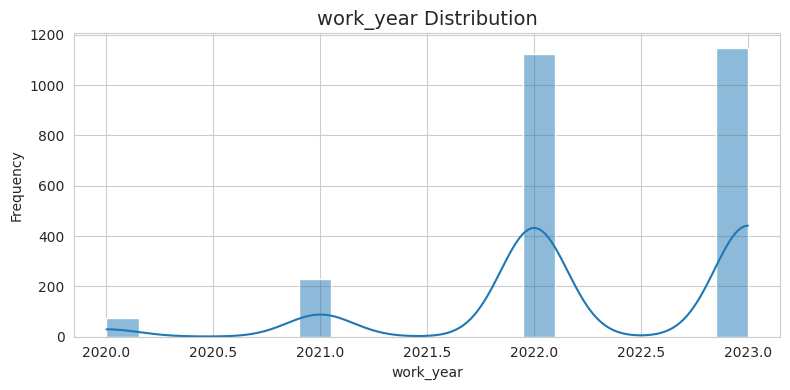

work_year: Not Gaussian (p=0.00000)
------------------------------------------------------------


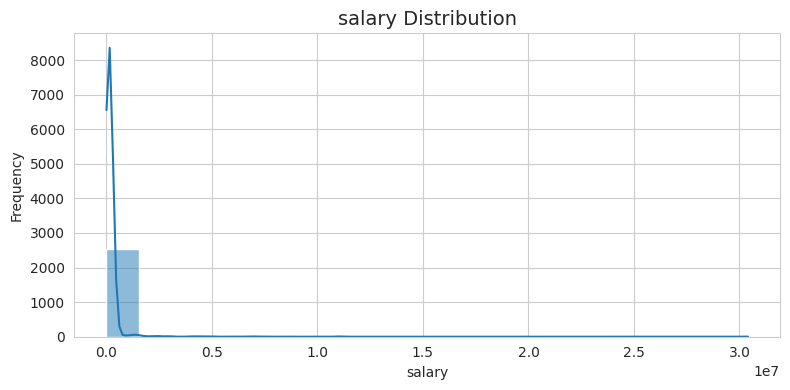

salary: Not Gaussian (p=0.00000)
------------------------------------------------------------


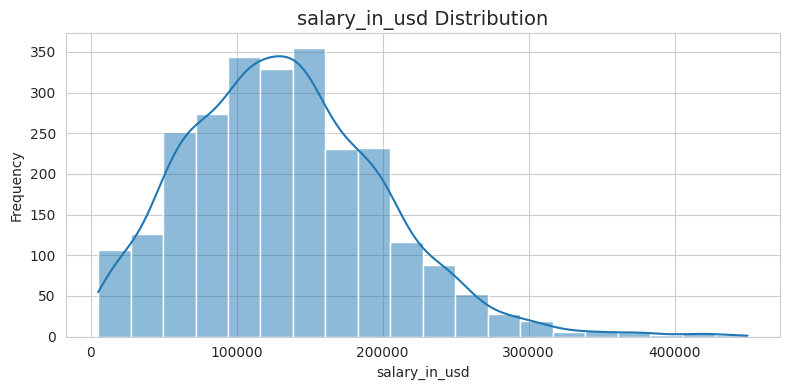

salary_in_usd: Not Gaussian (p=0.00000)
------------------------------------------------------------


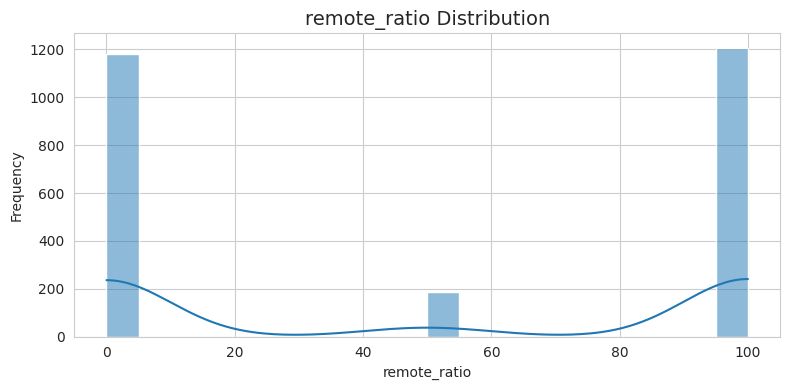

remote_ratio: Not Gaussian (p=0.00000)
------------------------------------------------------------


In [ ]:
plot_numeric_distributions(df)

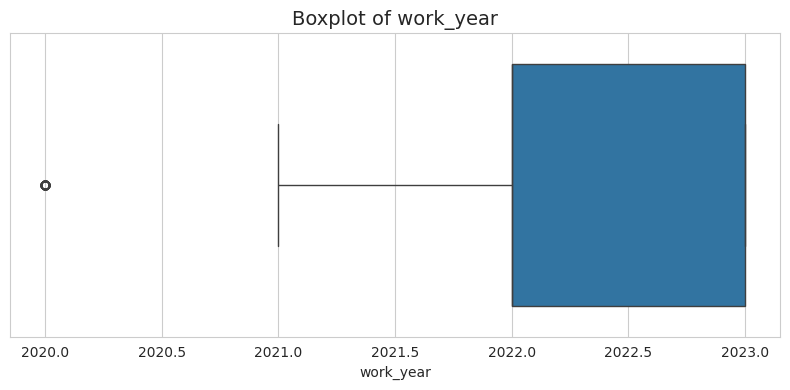

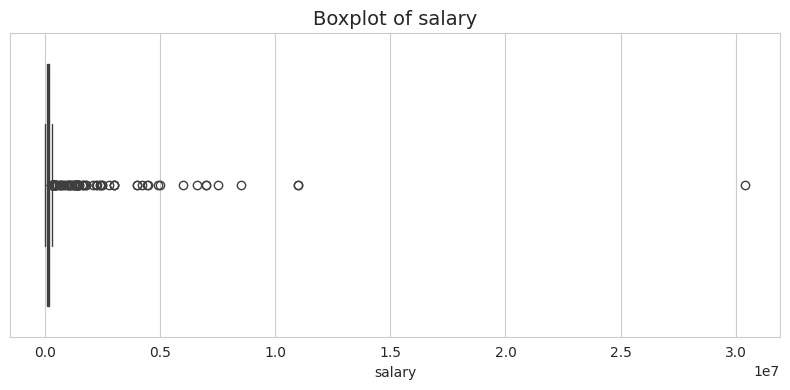

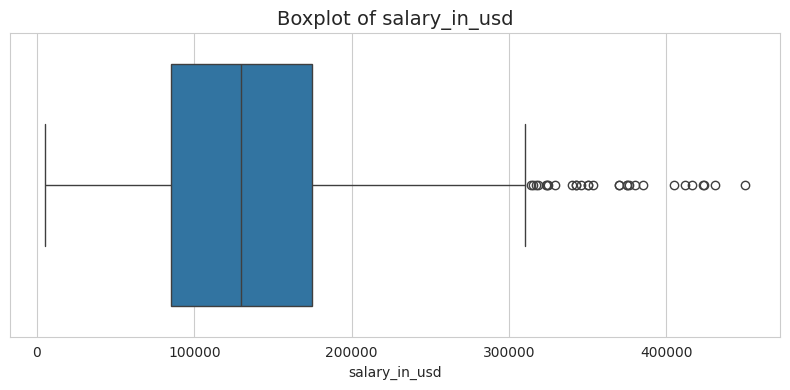

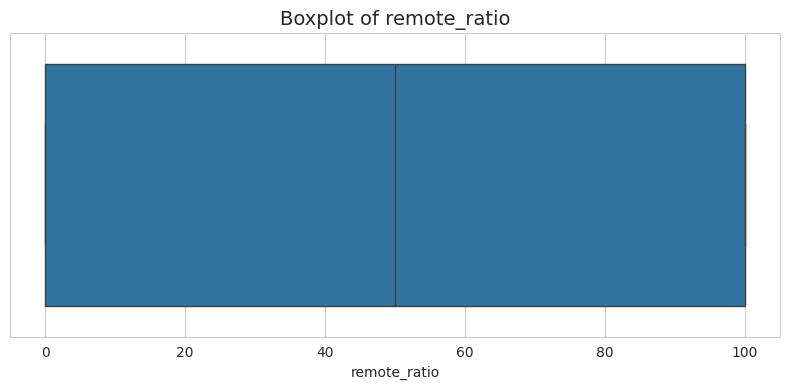

In [ ]:
plot_numeric_boxplots(df)

Found 8 categorical columns.


<ipython-input-30-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


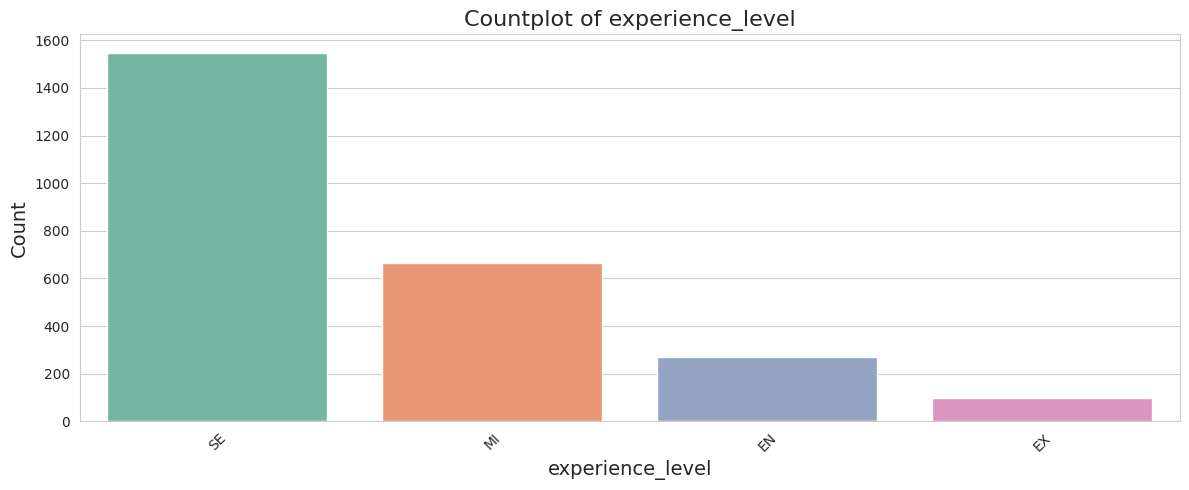

<ipython-input-30-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


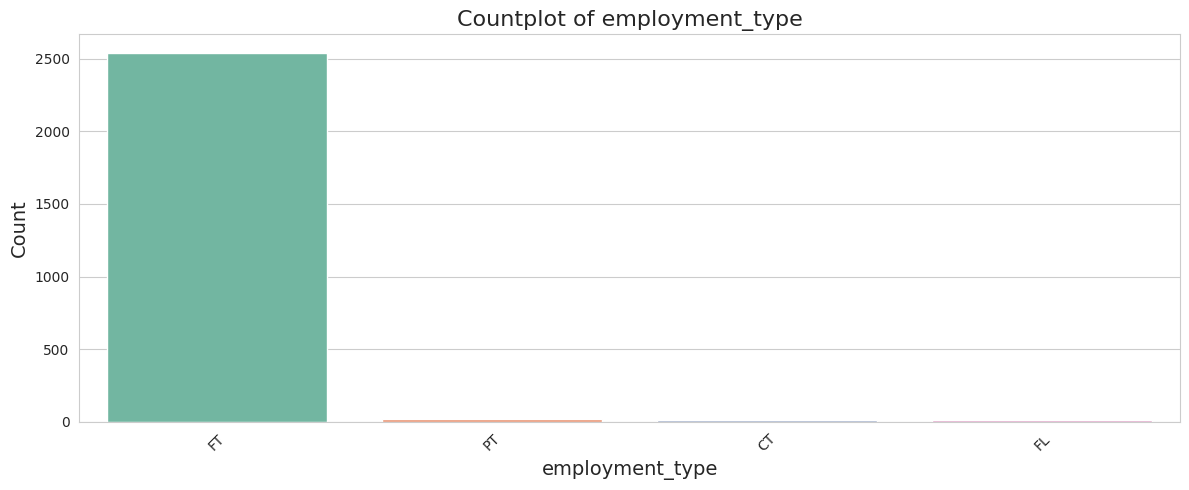

<ipython-input-30-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


Skipping job_title (too many unique values: 93)


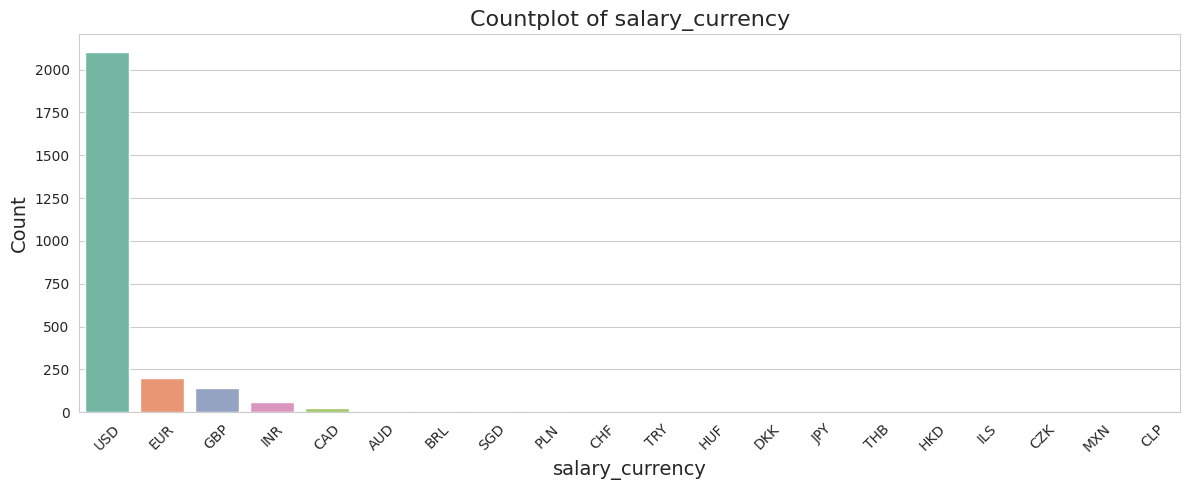

<ipython-input-30-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


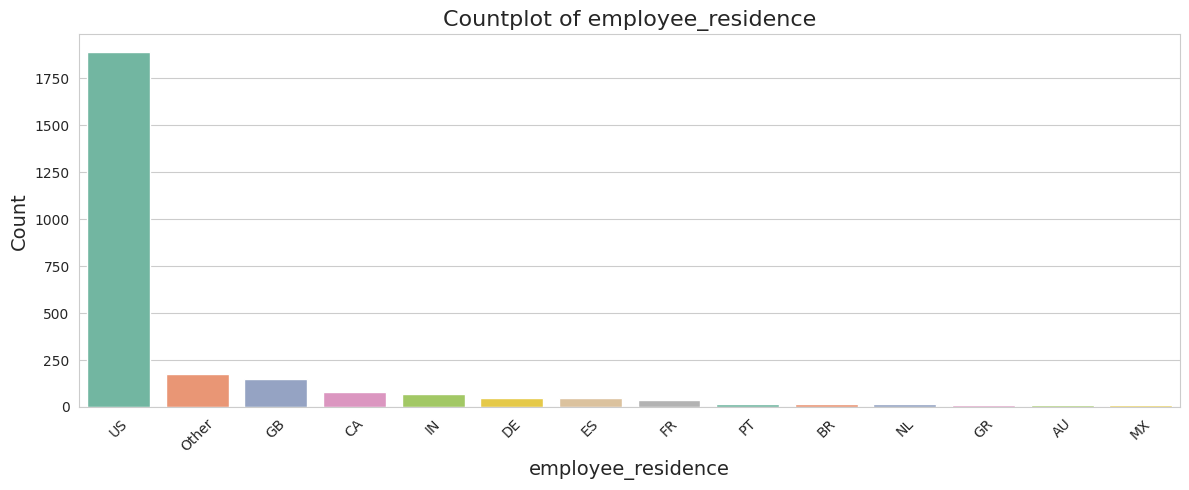

<ipython-input-30-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


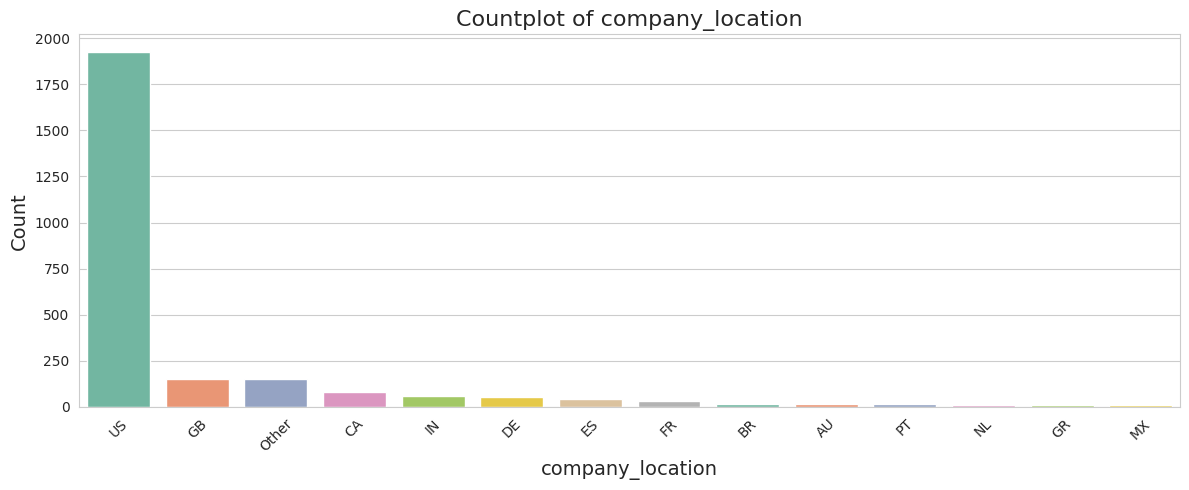

<ipython-input-30-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


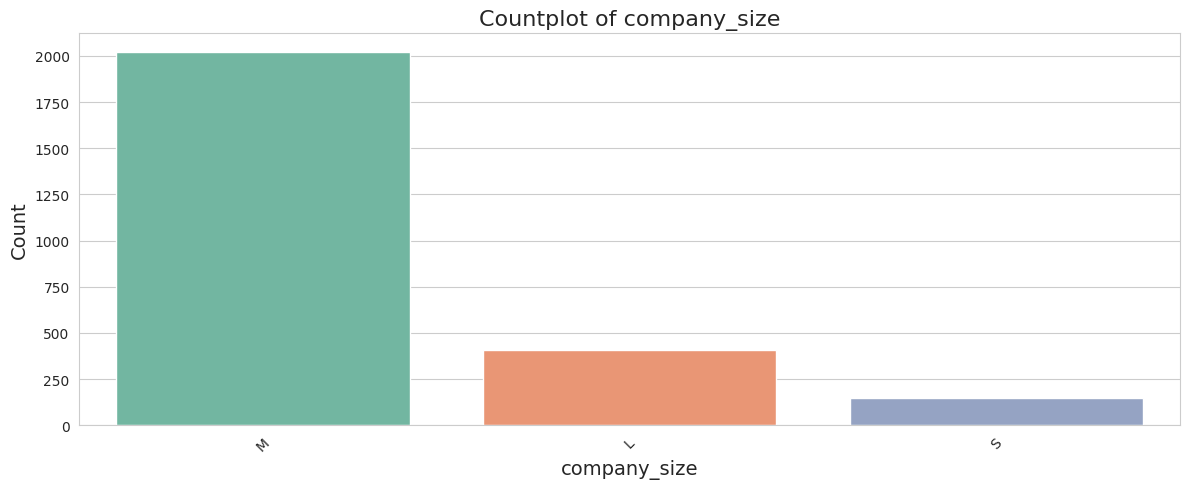

<ipython-input-30-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


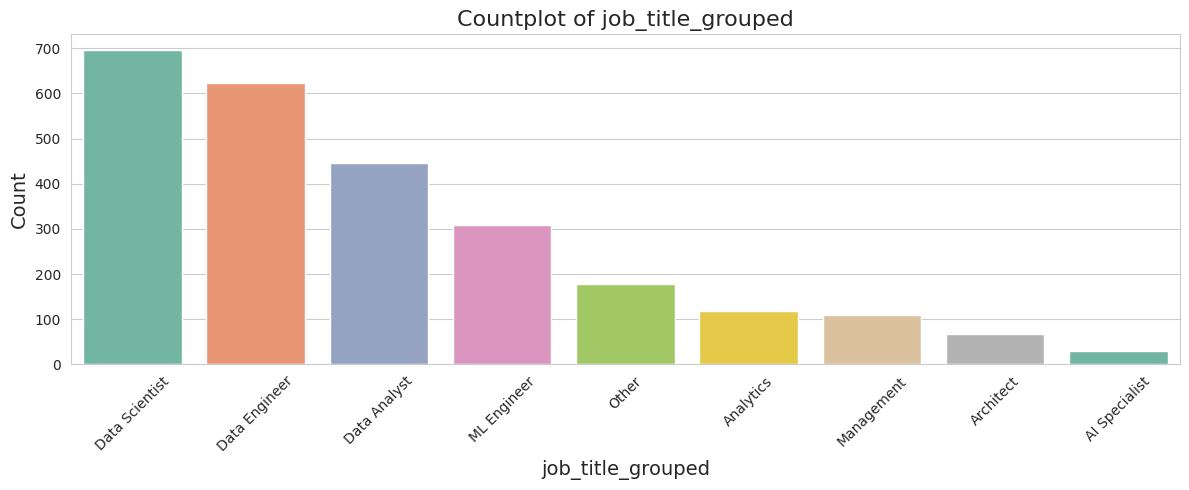

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
def plot_categorical_features(df, max_unique=30):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    print(f"Found {len(categorical_cols)} categorical columns.")

    for col in categorical_cols:
        if df[col].nunique() <= max_unique:
            plt.figure(figsize=(12, 5))
            sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)
            plt.title(f'Countplot of {col}', fontsize=16)
            plt.xlabel(col, fontsize=14)
            plt.ylabel('Count', fontsize=14)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print(f"Skipping {col} (too many unique values: {df[col].nunique()})")

plot_categorical_features(df)

In [ ]:
def show_categorical_value_percentages(df):
    dist_check = df.select_dtypes(include=['object', 'category']).columns.tolist()
    # add remote ratio to this categorical_cols
    dist_check.append('remote_ratio')

    for col in dist_check:
        print(f"\nFeature: '{col}'")
        value_counts = df[col].value_counts(dropna=False)
        total = len(df)
        for val, count in value_counts.items():
            percent = (count / total) * 100
            print(f" - {repr(val)}: {count} ({percent:.2f}%)")

show_categorical_value_percentages(df)


Feature: 'experience_level'
 - 'SE': 1548 (60.07%)
 - 'MI': 663 (25.73%)
 - 'EN': 270 (10.48%)
 - 'EX': 96 (3.73%)

Feature: 'employment_type'
 - 'FT': 2540 (98.56%)
 - 'PT': 17 (0.66%)
 - 'CT': 10 (0.39%)
 - 'FL': 10 (0.39%)

Feature: 'job_title'
 - 'Data Engineer': 594 (23.05%)
 - 'Data Scientist': 539 (20.92%)
 - 'Data Analyst': 396 (15.37%)
 - 'Machine Learning Engineer': 205 (7.95%)
 - 'Analytics Engineer': 89 (3.45%)
 - 'Research Scientist': 65 (2.52%)
 - 'Data Architect': 64 (2.48%)
 - 'Data Science Manager': 52 (2.02%)
 - 'ML Engineer': 34 (1.32%)
 - 'Research Engineer': 33 (1.28%)
 - 'Applied Scientist': 31 (1.20%)
 - 'Machine Learning Scientist': 26 (1.01%)
 - 'Data Manager': 23 (0.89%)
 - 'Data Science Consultant': 23 (0.89%)
 - 'Computer Vision Engineer': 18 (0.70%)
 - 'Data Analytics Manager': 18 (0.70%)
 - 'AI Scientist': 16 (0.62%)
 - 'BI Data Analyst': 15 (0.58%)
 - 'Business Data Analyst': 15 (0.58%)
 - 'Applied Machine Learning Scientist': 12 (0.47%)
 - 'Data Special

<ipython-input-27-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


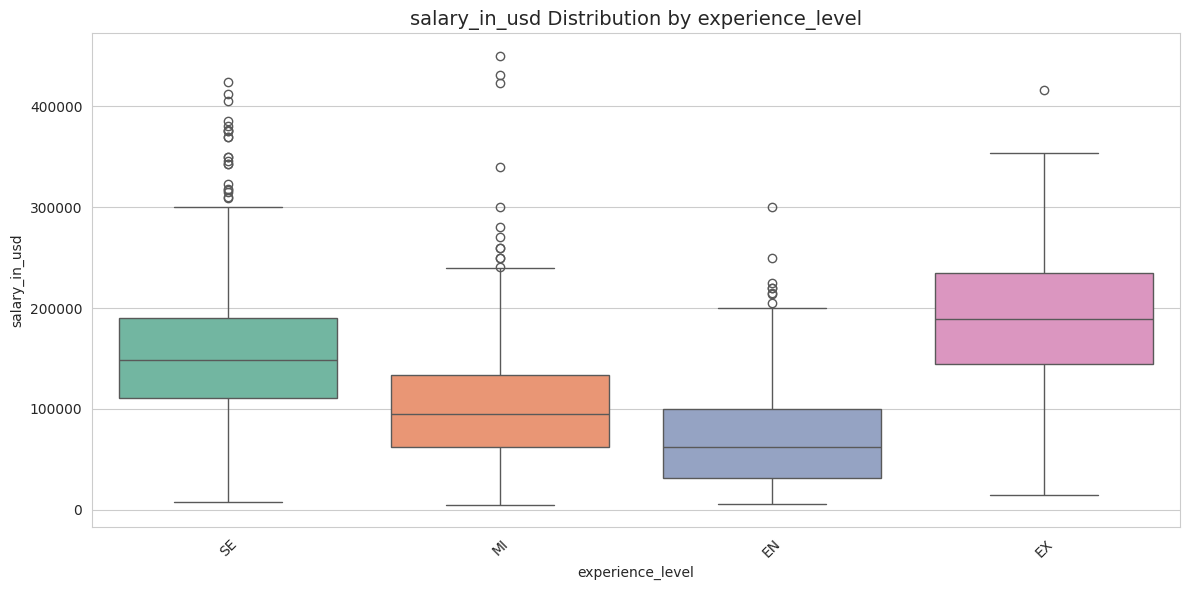

<ipython-input-27-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


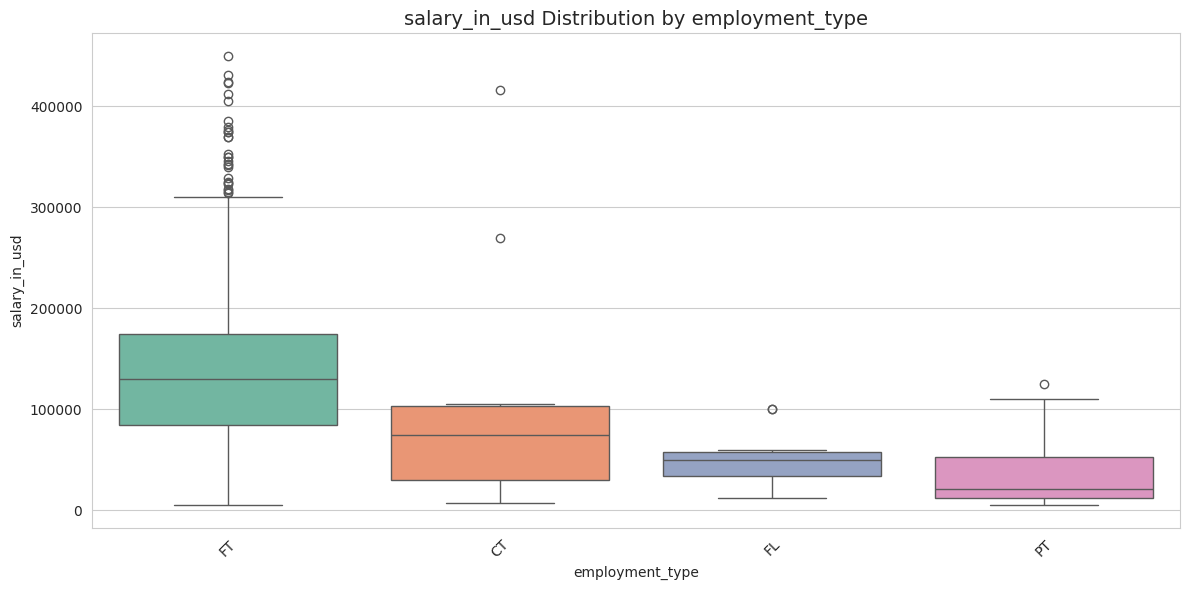

<ipython-input-27-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


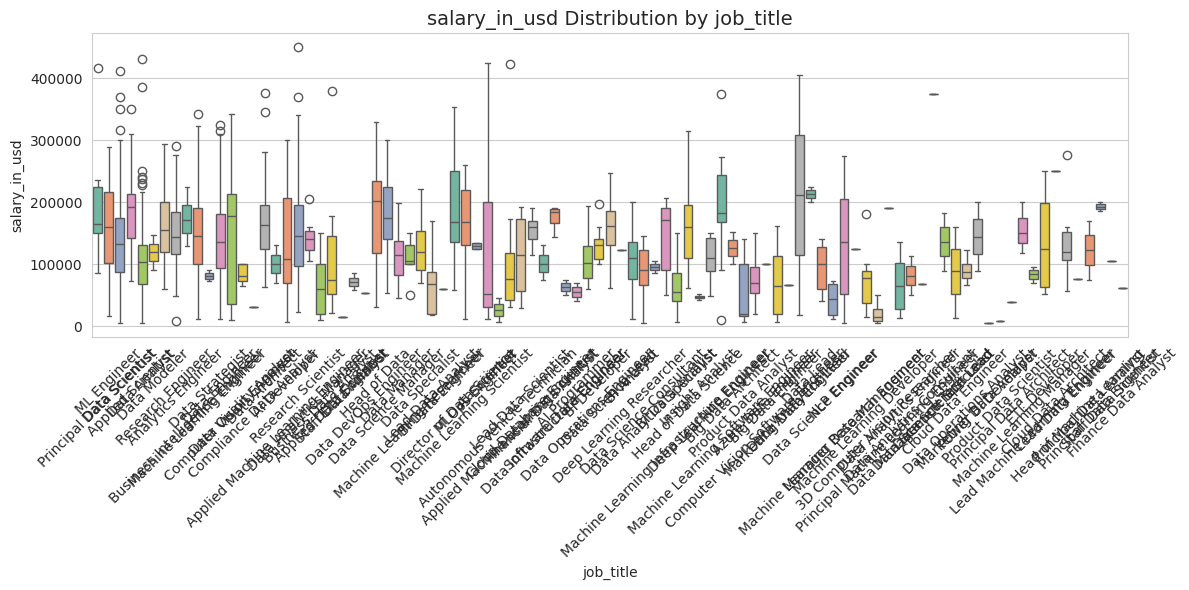

<ipython-input-27-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


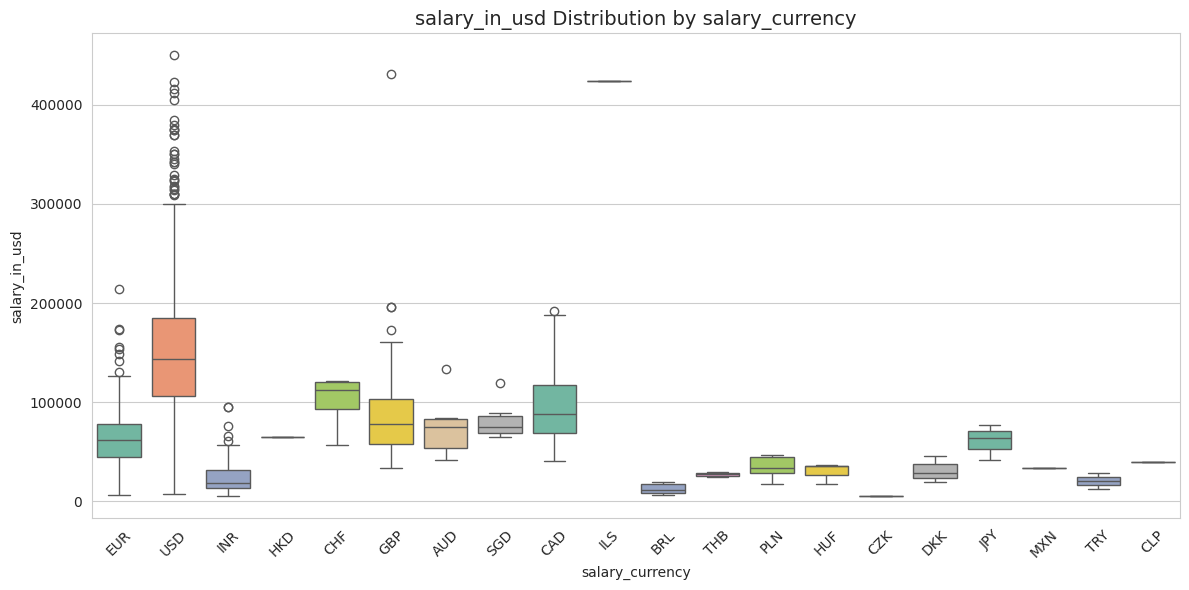

<ipython-input-27-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


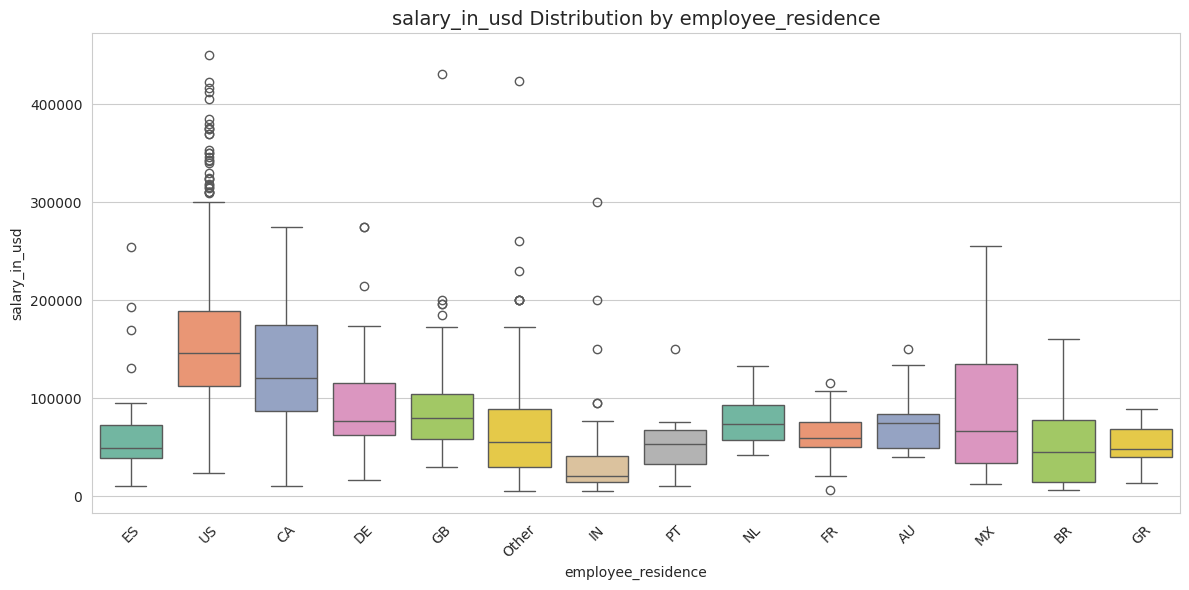

<ipython-input-27-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


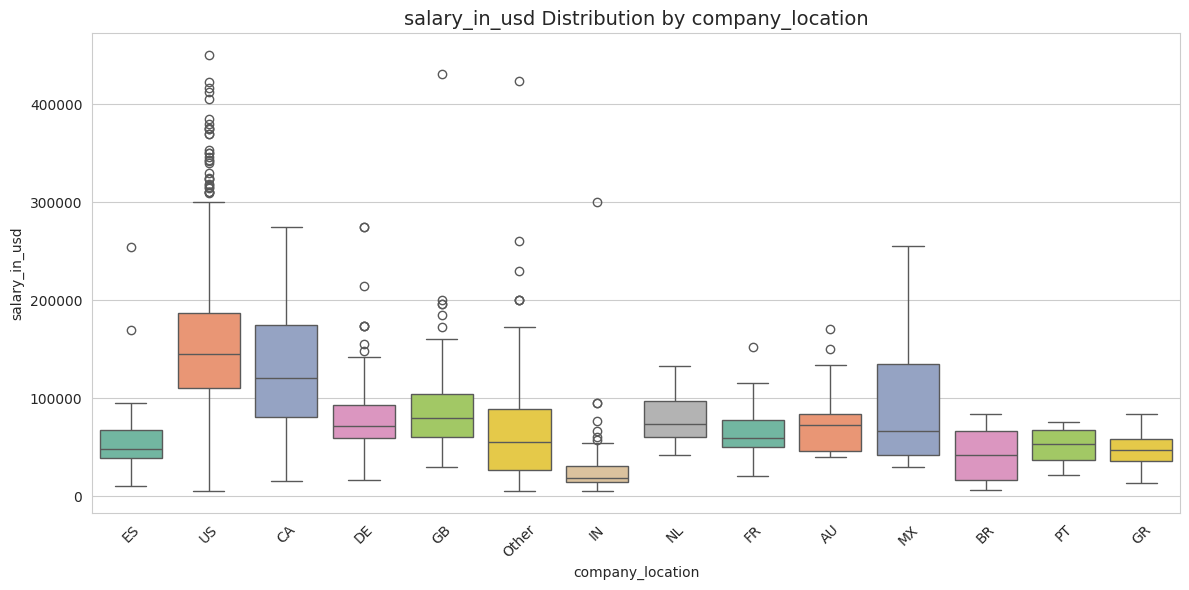

<ipython-input-27-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


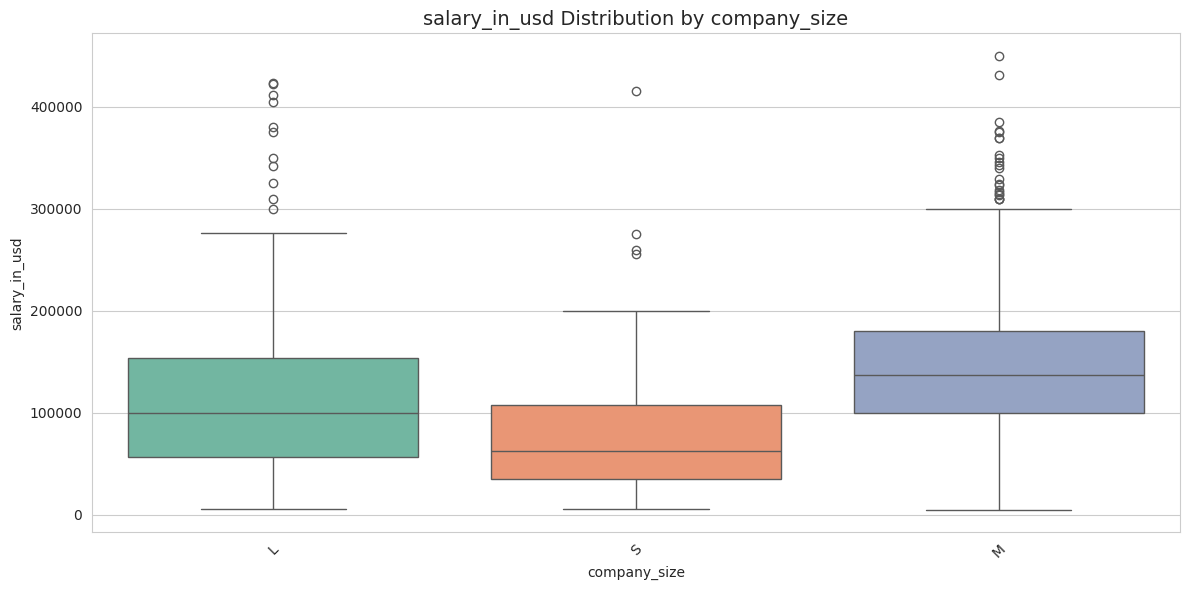

<ipython-input-27-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


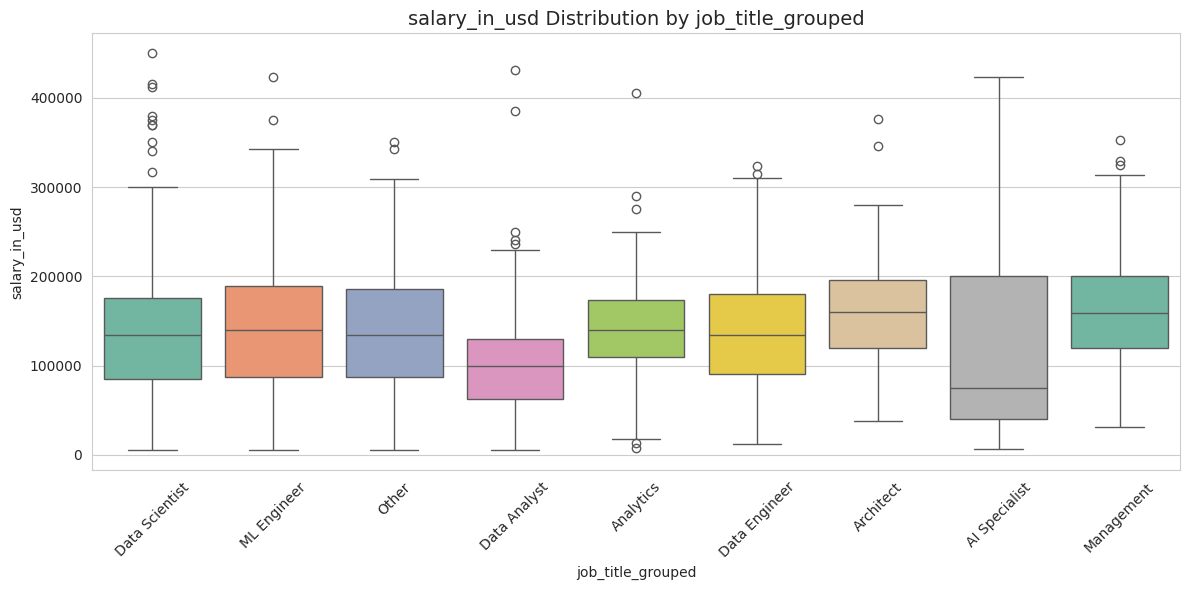

In [ ]:
plot_salary_vs_categorical(df)

In [ ]:
plot_outlier_summary(df)


=== Outlier Detection Summary ===
work_year: 75 outliers detected
salary: 95 outliers detected
salary_in_usd: 29 outliers detected
remote_ratio: 0 outliers detected


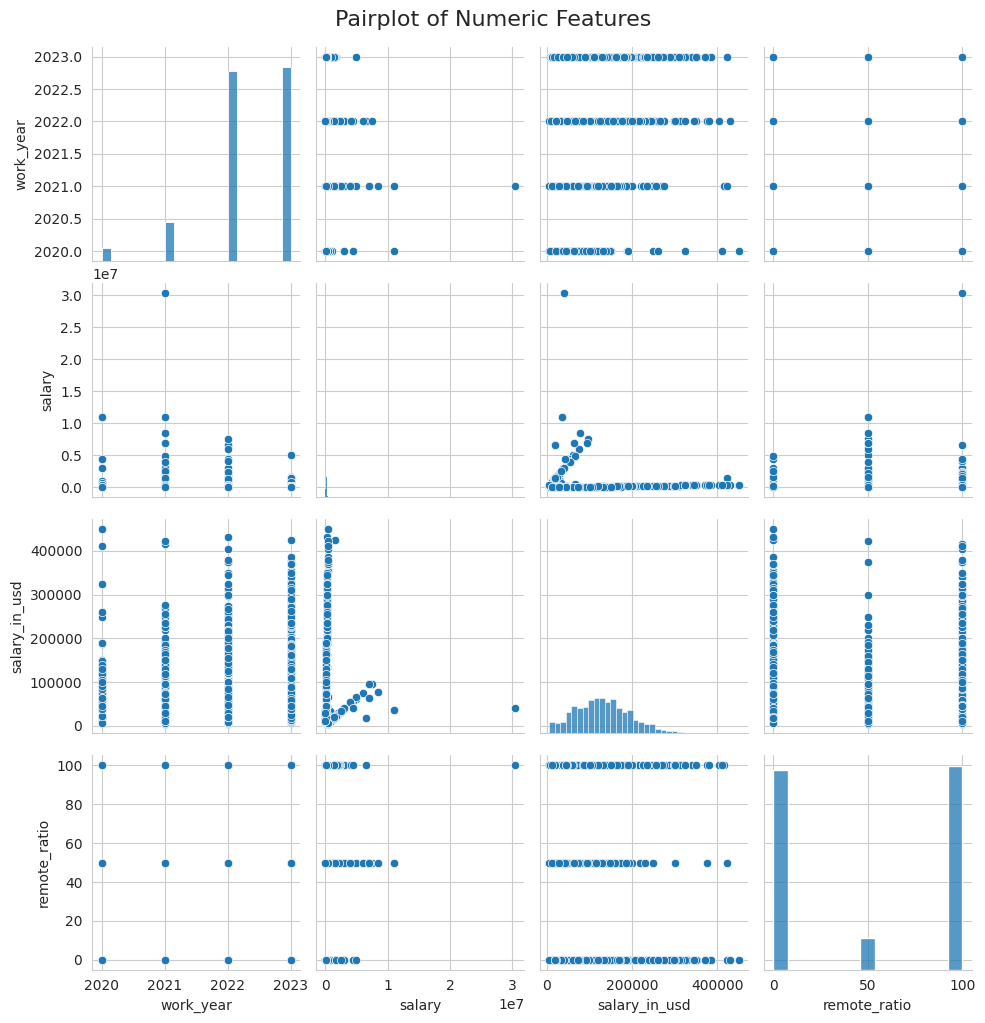

In [ ]:
plot_pairplot(df)

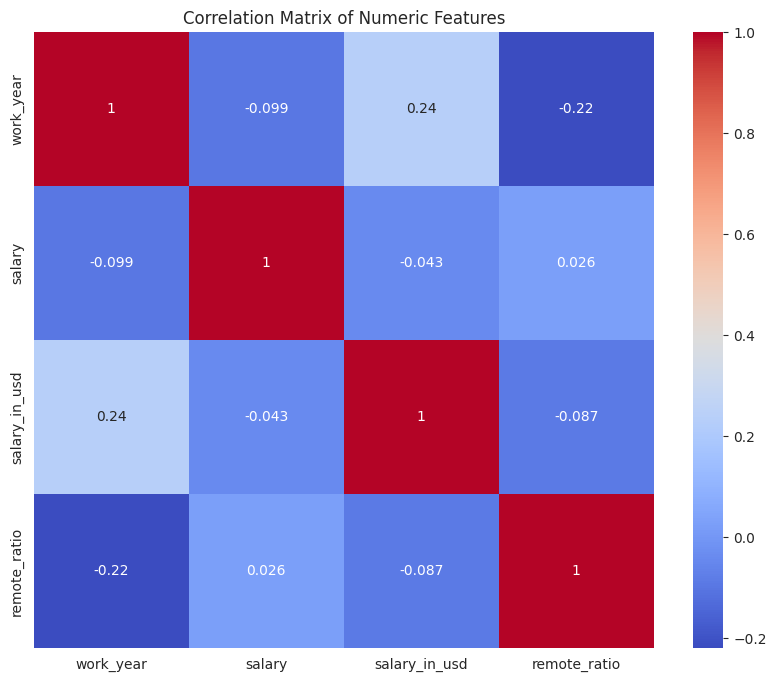

In [ ]:
# 5. Correlation Matrix Heatmap for Numerical
def plot_correlation_matrix(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
    plt.title("Correlation Matrix of Numeric Features")
    plt.show()

plot_correlation_matrix(df)

**Reasoning**:
Analyze the distribution of salary across different job titles, experience levels, employment types, and company sizes. Identify potential outliers in the salary variable. Visualize the relationship between 'salary_in_usd' and other numerical features. Quantify potential outliers using the IQR method.



## Data wrangling / Feature Engineering

### Subtask:
Convert categorical features to numerical representations and create new features if necessary.


**Reasoning**:
Identify categorical features, apply one-hot encoding, and create new features.



In [ ]:
#Binary Features based on remote work
df['is_remote'] = (df['remote_ratio'] == 100).astype(int)
df['is_onsite'] = (df['remote_ratio'] == 0).astype(int)
df['is_hybrid'] = (df['remote_ratio'] == 50).astype(int)

#Binary Feature for full-time employment
df['is_fulltime'] = (df['employment_type'] == 'FT').astype(int)

# === Ordinal Encoding for Experience Level
experience_mapping = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
df['experience_level_encoded'] = df['experience_level'].map(experience_mapping)

# === Ordinal Encoding for Company Size
company_size_mapping = {'S': 0, 'M': 1, 'L': 2}
df['company_size_encoded'] = df['company_size'].map(company_size_mapping)

# === Binary Feature for Salary Currency
df['is_usd_salary'] = (df['salary_currency'] == 'USD').astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2577 entries, 0 to 2587
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   work_year                 2577 non-null   float64
 1   experience_level          2577 non-null   object 
 2   employment_type           2577 non-null   object 
 3   job_title                 2577 non-null   object 
 4   salary                    2577 non-null   float64
 5   salary_currency           2577 non-null   object 
 6   salary_in_usd             2577 non-null   float64
 7   employee_residence        2577 non-null   object 
 8   remote_ratio              2577 non-null   float64
 9   company_location          2577 non-null   object 
 10  company_size              2577 non-null   object 
 11  job_title_grouped         2577 non-null   object 
 12  is_remote                 2577 non-null   int64  
 13  is_onsite                 2577 non-null   int64  
 14  is_hybrid    

In [ ]:
# Drop original columns after feature engineering and data preprocessing
df.drop(['remote_ratio', 'experience_level', 'company_size', 'employment_type', 'salary_currency','job_title','salary'], axis=1, inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2577 entries, 0 to 2587
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   work_year                 2577 non-null   float64
 1   salary_in_usd             2577 non-null   float64
 2   employee_residence        2577 non-null   object 
 3   company_location          2577 non-null   object 
 4   job_title_grouped         2577 non-null   object 
 5   is_remote                 2577 non-null   int64  
 6   is_onsite                 2577 non-null   int64  
 7   is_hybrid                 2577 non-null   int64  
 8   is_fulltime               2577 non-null   int64  
 9   experience_level_encoded  2577 non-null   int64  
 10  company_size_encoded      2577 non-null   int64  
 11  is_usd_salary             2577 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 261.7+ KB


In [ ]:
import pandas as pd

# One-Hot Encode selected categorical variables
df_encoded = pd.get_dummies(df, columns=['employee_residence', 'company_location', 'job_title_grouped'], drop_first=True)

# Inspect the modified DataFrame
display(df_encoded.head())
print(df_encoded.shape)
print(df_encoded.dtypes)

,work_year,salary_in_usd,is_remote,is_onsite,is_hybrid,is_fulltime,experience_level_encoded,company_size_encoded,is_usd_salary,employee_residence_BR,...,company_location_PT,company_location_US,job_title_grouped_Analytics,job_title_grouped_Architect,job_title_grouped_Data Analyst,job_title_grouped_Data Engineer,job_title_grouped_Data Scientist,job_title_grouped_ML Engineer,job_title_grouped_Management,job_title_grouped_Other
0,2023.0,85847.0,1,0,0,1,2,2,0,False,...,False,False,False,False,False,False,True,False,False,False
1,2023.0,30000.0,1,0,0,0,1,0,1,False,...,False,True,False,False,False,False,False,True,False,False
2,2023.0,25500.0,1,0,0,0,1,0,1,False,...,False,True,False,False,False,False,False,True,False,False
3,2023.0,175000.0,1,0,0,1,2,1,1,False,...,False,False,False,False,False,False,True,False,False,False
4,2023.0,120000.0,1,0,0,1,2,1,1,False,...,False,False,False,False,False,False,True,False,False,False


(2577, 43)
work_year                           float64
salary_in_usd                       float64
is_remote                             int64
is_onsite                             int64
is_hybrid                             int64
is_fulltime                           int64
experience_level_encoded              int64
company_size_encoded                  int64
is_usd_salary                         int64
employee_residence_BR                  bool
employee_residence_CA                  bool
employee_residence_DE                  bool
employee_residence_ES                  bool
employee_residence_FR                  bool
employee_residence_GB                  bool
employee_residence_GR                  bool
employee_residence_IN                  bool
employee_residence_MX                  bool
employee_residence_NL                  bool
employee_residence_Other               bool
employee_residence_PT                  bool
employee_residence_US                  bool
company_location_BR  

| Feature | Formula | Justification (Why It Makes Sense) |
|:---|:---|:---|
| `year_experience_interaction` | `work_year * experience_level_encoded` | **Experience maturity over years**: A Senior Employee in 2023 likely earns much more than a Senior Employee in 2020. `work_year` captures the time trend, `experience_level_encoded` captures seniority. Their combination models how seniority across different years affects salary. |
| `year_remote_interaction` | `work_year * is_remote` | **Remote work evolution over time**: Remote work became common after 2020 (COVID-19 effect). Combining `work_year` with `is_remote` models how salaries for remote roles evolved differently compared to onsite roles. |
| `experience_remote_interaction` | `experience_level_encoded * is_remote` | **Remote Senior vs Junior gap**: A Senior Remote worker (e.g., Engineering Manager fully remote) likely negotiates better salaries than an Entry-level Remote worker. Captures seniority-specific remote work salary effects. |
| `experience_onsite_interaction` | `experience_level_encoded * is_onsite` | **Onsite Senior vs Junior gap**: A Senior Onsite employee (e.g., Head of Analytics onsite) probably commands a different salary premium compared to an Entry-level Onsite worker. Models onsite-specific seniority salary trends. |


In [ ]:
# Interaction: Year * Experience Level
df_encoded['year_experience_interaction'] = df_encoded['work_year'] * df_encoded['experience_level_encoded']

# Interaction: Year * is_remote
df_encoded['year_remote_interaction'] = df_encoded['work_year'] * df_encoded['is_remote']

# Interaction: Experience Level * is_remote
df_encoded['experience_remote_interaction'] = df_encoded['experience_level_encoded'] * df_encoded['is_remote']

# Interaction: Experience Level * is_onsite
df_encoded['experience_onsite_interaction'] = df_encoded['experience_level_encoded'] * df_encoded['is_onsite']


In [ ]:
correlation_matrix_check = df_encoded[['salary_in_usd', 'year_experience_interaction', 'year_remote_interaction','experience_remote_interaction','experience_onsite_interaction']].corr()
#plot correaltion matrix
correlation_matrix_check.style.background_gradient(cmap='coolwarm')



,salary_in_usd,year_experience_interaction,year_remote_interaction,experience_remote_interaction,experience_onsite_interaction
salary_in_usd,1.000000,0.470186,-0.024215,0.172536,0.237639
year_experience_interaction,0.470186,1.000000,0.007965,0.371627,0.393247
year_remote_interaction,-0.024215,0.007965,1.000000,0.845467,-0.760796
experience_remote_interaction,0.172536,0.371627,0.845467,1.000000,-0.643187
experience_onsite_interaction,0.237639,0.393247,-0.760796,-0.643187,1.000000


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Define X (drop the target)
X_variance_check = df_encoded.drop('salary_in_usd', axis=1)

# Apply VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_variance_check)

# Get variances of all features
feature_variances = pd.Series(selector.variances_, index=X_variance_check.columns)

# Sort variances nicely (optional)
feature_variances_sorted = feature_variances.sort_values(ascending=False)

# Display variances
print("=== Feature Variances ===")
for feature, variance in feature_variances_sorted.items():
    print(f"{feature}: {variance:.6f}")

# Selected columns (above threshold)
selected_columns_variance = X_variance_check.columns[selector.get_support()]

print("\n=== Final Selected Features ===")
print(f"Original number of features: {X_variance_check.shape[1]}")
print(f"Number of features after Variance Threshold: {len(selected_columns_variance)}")
print(f"Selected Features: {selected_columns_variance.tolist()}")


=== Feature Variances ===
year_experience_interaction: 2164170.139275
year_remote_interaction: 1018222.176122
experience_onsite_interaction: 0.885005
experience_remote_interaction: 0.866014
work_year: 0.561245
experience_level_encoded: 0.529091
is_remote: 0.249000
is_onsite: 0.248324
company_size_encoded: 0.205418
job_title_grouped_Data Scientist: 0.197137
employee_residence_US: 0.195700
company_location_US: 0.189186
job_title_grouped_Data Engineer: 0.183108
is_usd_salary: 0.150593
job_title_grouped_Data Analyst: 0.143370
job_title_grouped_ML Engineer: 0.105234
is_hybrid: 0.067299
job_title_grouped_Other: 0.064302
employee_residence_Other: 0.062961
company_location_GB: 0.056188
company_location_Other: 0.055162
employee_residence_GB: 0.054476
job_title_grouped_Analytics: 0.044045
job_title_grouped_Management: 0.040863
company_location_CA: 0.031171
employee_residence_CA: 0.030080
employee_residence_IN: 0.026426
job_title_grouped_Architect: 0.025691
company_location_IN: 0.021630
company_l

In [ ]:
# Calculate full correlation matrix
corr_matrix = df_encoded.corr()

# Focus only on correlation with 'salary_in_usd'
corr_with_target = corr_matrix['salary_in_usd'].drop('salary_in_usd')  # Drop self-correlation

# Display sorted correlations
corr_with_target_sorted = corr_with_target.sort_values(ascending=False)

print("=== Correlation of Features with salary_in_usd ===")
for feature, corr_value in corr_with_target_sorted.items():
    print(f"{feature}: {corr_value:.6f}")

=== Correlation of Features with salary_in_usd ===
employee_residence_US: 0.507625
company_location_US: 0.485778
is_usd_salary: 0.471994
year_experience_interaction: 0.470186
experience_level_encoded: 0.470087
experience_onsite_interaction: 0.237639
work_year: 0.235759
experience_remote_interaction: 0.172536
is_onsite: 0.143292
is_fulltime: 0.126820
job_title_grouped_Management: 0.101551
job_title_grouped_Architect: 0.079989
job_title_grouped_ML Engineer: 0.049993
job_title_grouped_Data Engineer: 0.046834
job_title_grouped_Analytics: 0.029696
job_title_grouped_Other: 0.014695
job_title_grouped_Data Scientist: 0.013496
company_size_encoded: -0.001695
employee_residence_CA: -0.005033
company_location_CA: -0.007301
year_remote_interaction: -0.024215
is_remote: -0.024270
company_location_MX: -0.033620
employee_residence_MX: -0.038090
company_location_NL: -0.057917
employee_residence_NL: -0.063669
employee_residence_DE: -0.078081
company_location_GR: -0.084439
employee_residence_GR: -0.0866

<ipython-input-45-7e9aabda76d1>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target_sorted.values, y=corr_with_target_sorted.index, palette="coolwarm")


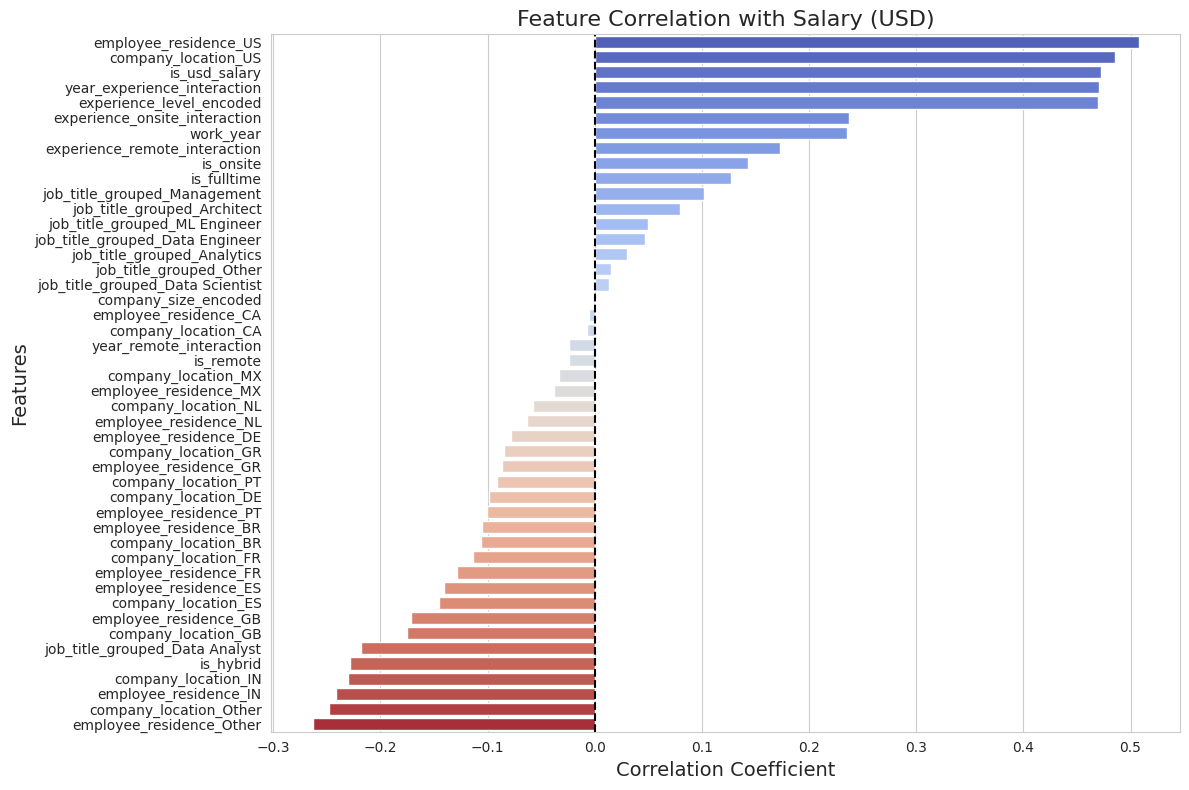

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the sorted correlations
plt.figure(figsize=(12, 8))
sns.barplot(x=corr_with_target_sorted.values, y=corr_with_target_sorted.index, palette="coolwarm")
plt.title('Feature Correlation with Salary (USD)', fontsize=16)
plt.xlabel('Correlation Coefficient', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(0, color='black', linestyle='--')  # Vertical line at 0
plt.tight_layout()
plt.show()


In [ ]:
# 2. Select features to KEEP (|corr| > 0.05)
selected_features_corr = corr_with_target[abs(corr_with_target) > 0.05].index.tolist()

# 3. Identify features to DROP (|corr| <= 0.05)
dropped_features_corr = corr_with_target[abs(corr_with_target) <= 0.05].index.tolist()

# 4. Print Results
print("\n=== Features Selected (|corr| > 0.05) ===")
for feat in selected_features_corr:
    print(f"{feat}")

print("\n=== Features Dropped (|corr| <= 0.05) ===")
for feat in dropped_features_corr:
    print(f"{feat}")


=== Features Selected (|corr| > 0.05) ===
work_year
is_onsite
is_hybrid
is_fulltime
experience_level_encoded
is_usd_salary
employee_residence_BR
employee_residence_DE
employee_residence_ES
employee_residence_FR
employee_residence_GB
employee_residence_GR
employee_residence_IN
employee_residence_NL
employee_residence_Other
employee_residence_PT
employee_residence_US
company_location_BR
company_location_DE
company_location_ES
company_location_FR
company_location_GB
company_location_GR
company_location_IN
company_location_NL
company_location_Other
company_location_PT
company_location_US
job_title_grouped_Architect
job_title_grouped_Data Analyst
job_title_grouped_Management
year_experience_interaction
experience_remote_interaction
experience_onsite_interaction

=== Features Dropped (|corr| <= 0.05) ===
is_remote
company_size_encoded
employee_residence_CA
employee_residence_MX
company_location_CA
company_location_MX
job_title_grouped_Analytics
job_title_grouped_Data Engineer
job_title_grou

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2577 entries, 0 to 2587
Data columns (total 47 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   work_year                         2577 non-null   float64
 1   salary_in_usd                     2577 non-null   float64
 2   is_remote                         2577 non-null   int64  
 3   is_onsite                         2577 non-null   int64  
 4   is_hybrid                         2577 non-null   int64  
 5   is_fulltime                       2577 non-null   int64  
 6   experience_level_encoded          2577 non-null   int64  
 7   company_size_encoded              2577 non-null   int64  
 8   is_usd_salary                     2577 non-null   int64  
 9   employee_residence_BR             2577 non-null   bool   
 10  employee_residence_CA             2577 non-null   bool   
 11  employee_residence_DE             2577 non-null   bool   
 12  employee_re

In [ ]:
df = df_encoded.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2577 entries, 0 to 2587
Data columns (total 47 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   work_year                         2577 non-null   float64
 1   salary_in_usd                     2577 non-null   float64
 2   is_remote                         2577 non-null   int64  
 3   is_onsite                         2577 non-null   int64  
 4   is_hybrid                         2577 non-null   int64  
 5   is_fulltime                       2577 non-null   int64  
 6   experience_level_encoded          2577 non-null   int64  
 7   company_size_encoded              2577 non-null   int64  
 8   is_usd_salary                     2577 non-null   int64  
 9   employee_residence_BR             2577 non-null   bool   
 10  employee_residence_CA             2577 non-null   bool   
 11  employee_residence_DE             2577 non-null   bool   
 12  employee_re

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,2577.0,2022.299185,0.749308,2020.0,2022.0,2022.0,2023.0,2023.0
salary_in_usd,2577.0,133255.215755,67038.624016,5132.0,84900.0,129400.0,175000.0,450000.0
is_remote,2577.0,0.468374,0.499096,0.0,0.0,0.0,1.0,1.0
is_onsite,2577.0,0.459061,0.498418,0.0,0.0,0.0,1.0,1.0
is_hybrid,2577.0,0.072565,0.259471,0.0,0.0,0.0,0.0,1.0
is_fulltime,2577.0,0.985642,0.118984,0.0,1.0,1.0,1.0,1.0
experience_level_encoded,2577.0,1.570431,0.727527,0.0,1.0,2.0,2.0,3.0
company_size_encoded,2577.0,1.101669,0.453319,0.0,1.0,1.0,1.0,2.0
is_usd_salary,2577.0,0.815289,0.388138,0.0,1.0,1.0,1.0,1.0
year_experience_interaction,2577.0,3175.994179,1471.397386,0.0,2022.0,4044.0,4046.0,6069.0


Normalization

In [ ]:
columns_to_scale = [
    'work_year',
    'year_experience_interaction',
    'year_remote_interaction',
    'experience_remote_interaction',
    'experience_onsite_interaction'
]

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,2577.0,2022.299185,0.749308,2020.0,2022.0,2022.0,2023.0,2023.0
salary_in_usd,2577.0,133255.215755,67038.624016,5132.0,84900.0,129400.0,175000.0,450000.0
is_remote,2577.0,0.468374,0.499096,0.0,0.0,0.0,1.0,1.0
is_onsite,2577.0,0.459061,0.498418,0.0,0.0,0.0,1.0,1.0
is_hybrid,2577.0,0.072565,0.259471,0.0,0.0,0.0,0.0,1.0
is_fulltime,2577.0,0.985642,0.118984,0.0,1.0,1.0,1.0,1.0
experience_level_encoded,2577.0,1.570431,0.727527,0.0,1.0,2.0,2.0,3.0
company_size_encoded,2577.0,1.101669,0.453319,0.0,1.0,1.0,1.0,2.0
is_usd_salary,2577.0,0.815289,0.388138,0.0,1.0,1.0,1.0,1.0
year_experience_interaction,2577.0,3175.994179,1471.397386,0.0,2022.0,4044.0,4046.0,6069.0


## Data splitting

### Subtask:
Split the data into training, validation, and testing sets.


**Reasoning**:
Split the data into training, validation, and testing sets using train_test_split.



In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('salary_in_usd', axis=1)
y = df['salary_in_usd']

# Split data into training and temporary sets (validation + testing)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split temporary set into validation and testing sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Print the shapes of the resulting sets to verify the split
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2061, 46)
y_train shape: (2061,)
X_val shape: (258, 46)
y_val shape: (258,)
X_test shape: (258, 46)
y_test shape: (258,)


In [ ]:
y_train = np.log1p(y_train)  # log(1 + salary)
y_val = np.log1p(y_val)
y_test = np.log1p(y_test)

Modelling

In [ ]:
# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


#MLP Test 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
# Define the model
def build_mlp_model(input_dim):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_dim=input_dim))
    model.add(Dropout(0.3))  # Regularization
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))  # Output layer, no activation (regression)

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

mlp_model = build_mlp_model(X_train_scaled.shape[1])
mlp_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,385 (64.00 KB)

 Trainable params: 16,385 (64.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Set EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# Train
history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 70.3144 - mae: 7.5587 - val_loss: 3.5079 - val_mae: 1.5650
Epoch 2/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1280 - mae: 1.9439 - val_loss: 1.1515 - val_mae: 0.9128
Epoch 3/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.7885 - mae: 1.7420 - val_loss: 1.0210 - val_mae: 0.8475
Epoch 4/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.9661 - mae: 1.5955 - val_loss: 0.7477 - val_mae: 0.7358
Epoch 5/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.2305 - mae: 1.4454 - val_loss: 0.8102 - val_mae: 0.7670
Epoch 6/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1198 - mae: 1.3898 - val_loss: 0.9629 - val_mae: 0.8504
Epoch 7/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7976 - mae: 1.3234 - val_loss: 1.1715 - val_mae: 0.9799
Epoch 8/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5612 - mae: 1.2817 - val_loss: 1.2004 - val_mae: 0.9883
Epoch 9/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.53

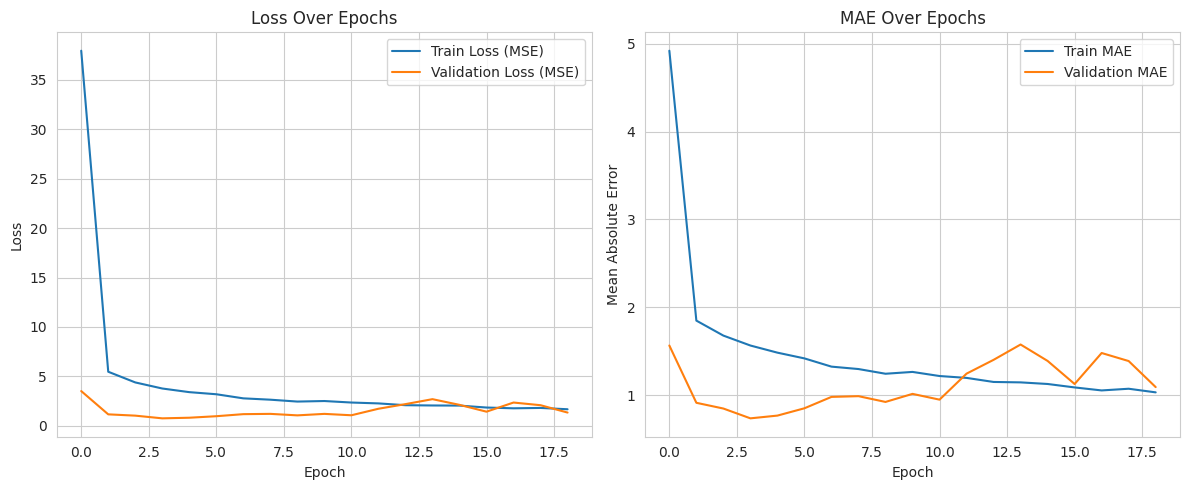

In [ ]:
def plot_learning_curves(history):
    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss (MSE)')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('MAE Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_learning_curves(history)


In [ ]:
# Predict
y_test_pred_nn = mlp_model.predict(X_test_scaled).flatten()

# Reverse log1p transform
y_test_actual_nn = np.expm1(y_test)
y_test_pred_actual_nn = np.expm1(y_test_pred_nn)

# Evaluate
def evaluate_model(y_true, y_pred, dataset_name="Test"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f" {dataset_name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")

evaluate_model(y_test_actual_nn, y_test_pred_actual_nn)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
📊 Test Performance:
R² Score: -0.8261
Mean Squared Error (MSE): 9278199026.72
Root Mean Squared Error (RMSE): 96323.41
Mean Absolute Error (MAE): 75630.04


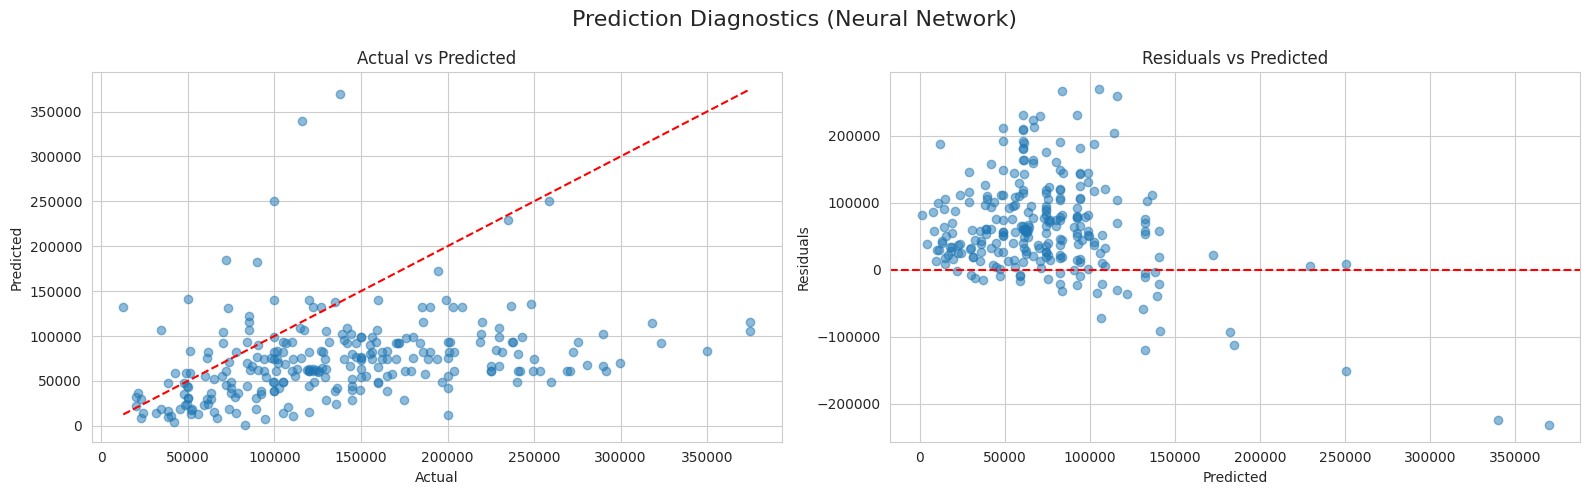

In [ ]:
def plot_prediction_diagnostics(y_true, y_pred, title="Prediction Diagnostics (Neural Network)"):
    residuals = y_true - y_pred

    plt.figure(figsize=(16, 5))

    # 1. Actual vs Predicted
    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Actual vs Predicted')

    # 2. Residuals
    plt.subplot(1, 2, 2)
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')
    plt.title('Residuals vs Predicted')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_prediction_diagnostics(y_test_actual_nn, y_test_pred_actual_nn)


Model Optimization

#MLP Test 2

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Build the improved MLP model
def build_stronger_mlp(input_dim):
    model = Sequential()
    model.add(Dense(256, activation='relu', input_dim=input_dim))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(1))  # No activation for regression

    optimizer = Adam(learning_rate=0.001)  # Slightly lower LR
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

stronger_mlp_model = build_stronger_mlp(X_train_scaled.shape[1])
stronger_mlp_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,041 (215.00 KB)

 Trainable params: 54,145 (211.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    verbose=1,
    min_lr=1e-6
)

history_stronger = stronger_mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 135.1422 - mae: 11.5197 - val_loss: 125.7006 - val_mae: 11.2002 - learning_rate: 0.0010
Epoch 2/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 115.1445 - mae: 10.6409 - val_loss: 101.1450 - val_mae: 10.0447 - learning_rate: 0.0010
Epoch 3/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 88.0838 - mae: 9.2630 - val_loss: 63.3483 - val_mae: 7.9410 - learning_rate: 0.0010
Epoch 4/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 54.8347 - mae: 7.1829 - val_loss: 28.8513 - val_mae: 5.3368 - learning_rate: 0.0010
Epoch 5/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25.3660 - mae: 4.6582 - val_loss: 9.1002 - val_mae: 2.9352 - learning_rate: 0.0010
Epoch 6/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10.4522 - mae: 2.6925 - val_loss: 2.8926 - val_mae: 1.5735 - learning_rate: 0.0010
Epoch 7/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0976 - mae: 1.9591 - val_loss: 0.9847 - val_mae: 0.7887 - learning_rate: 0

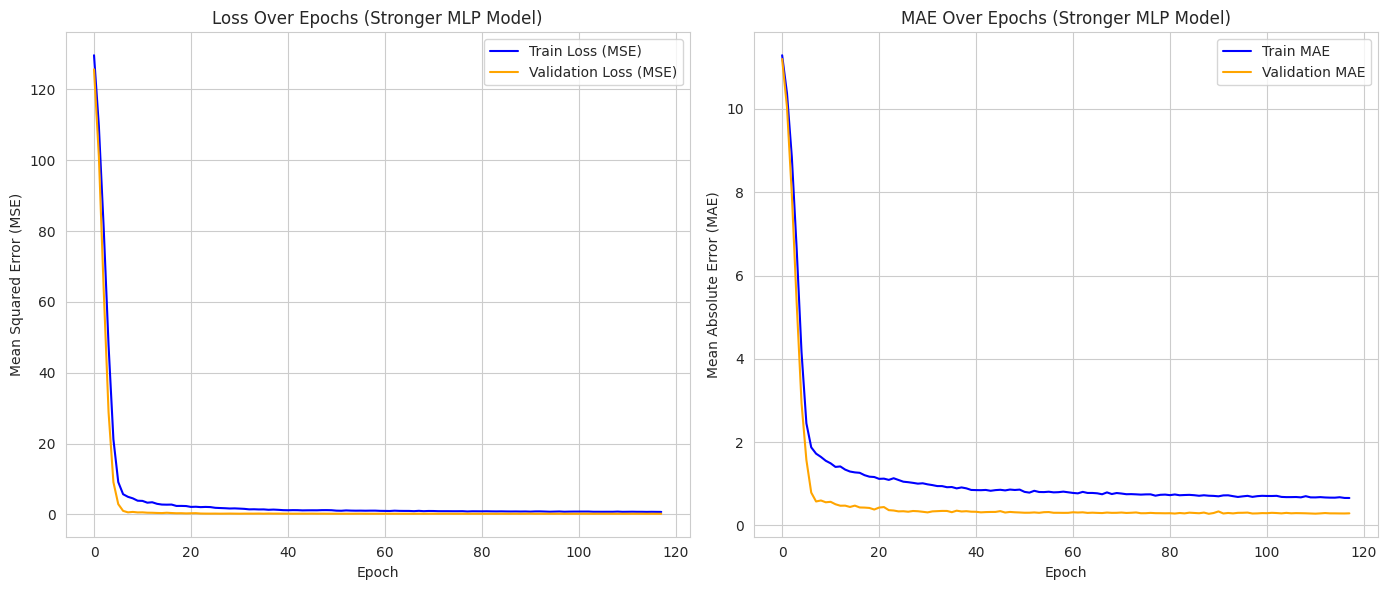

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(history, title_suffix=""):
    plt.figure(figsize=(14, 6))

    # 1. Plot Loss (MSE)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss (MSE)', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange')
    plt.title('Loss Over Epochs' + title_suffix)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.legend()
    plt.grid(True)

    # 2. Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE', color='blue')
    plt.plot(history.history['val_mae'], label='Validation MAE', color='orange')
    plt.title('MAE Over Epochs' + title_suffix)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error (MAE)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_learning_curves(history_stronger, title_suffix=" (Stronger MLP Model)")


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
📊 Test Performance:
R² Score: 0.3551
Mean Squared Error (MSE): 3276976156.93
Root Mean Squared Error (RMSE): 57244.88
Mean Absolute Error (MAE): 42142.20


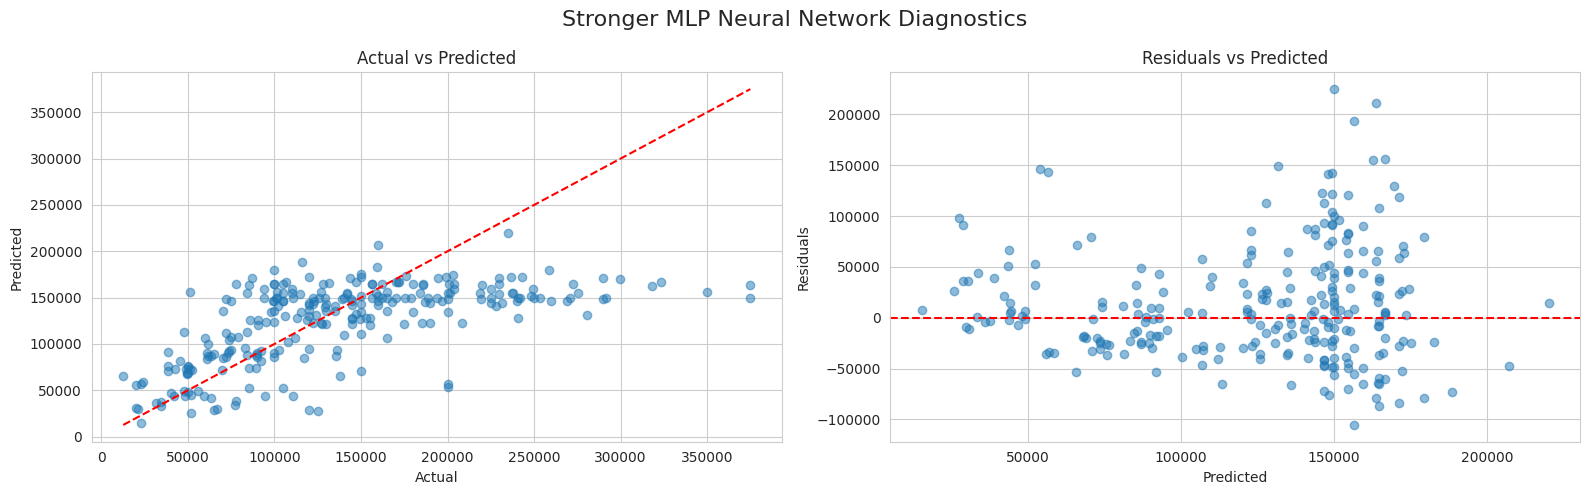

In [ ]:
# Predict
y_test_pred_stronger = stronger_mlp_model.predict(X_test_scaled).flatten()

# Reverse log1p
y_test_pred_actual_stronger = np.expm1(y_test_pred_stronger)
y_test_actual_stronger = np.expm1(y_test)

# Evaluate
evaluate_model(y_test_actual_stronger, y_test_pred_actual_stronger)

# Diagnostic plots
plot_prediction_diagnostics(y_test_actual_stronger, y_test_pred_actual_stronger, title="Stronger MLP Neural Network Diagnostics")


# Stage 1 : MLP Modelling


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# cale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Build Strong MLP Model
def build_mlp(input_dim):
    model = Sequential()
    model.add(Dense(256, activation='relu', input_dim=input_dim))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

In [ ]:
# Initialize
mlp_model = build_mlp(X_train_scaled.shape[1])
mlp_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,041 (215.00 KB)

 Trainable params: 54,145 (211.50 KB)

 Non-trainable params: 896 (3.50 KB)

A Multi-Layer Perceptron (MLP) model was chosen for its ability to model complex non-linear relationships between input features and salary. The architecture consisted of three hidden layers (256-128-64 neurons) with ReLU activations, Batch Normalization, and Dropout for regularization. This design allowed the model to progressively learn hierarchical feature abstractions while controlling for overfitting. The Adam optimizer, EarlyStopping, and ReduceLROnPlateau callbacks were incorporated to enhance training stability and efficiency. Given the moderate size and complexity of the dataset, this architecture was well-suited to achieving good generalization performance.

In [ ]:
# Setup Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    verbose=1,
    min_lr=1e-6
)

# Train
history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 133.7482 - mae: 11.4547 - val_loss: 121.0256 - val_mae: 10.9887 - learning_rate: 0.0010
Epoch 2/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 113.6874 - mae: 10.5803 - val_loss: 94.5418 - val_mae: 9.7100 - learning_rate: 0.0010
Epoch 3/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 86.8212 - mae: 9.1873 - val_loss: 60.0741 - val_mae: 7.7276 - learning_rate: 0.0010
Epoch 4/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 54.4171 - mae: 7.1583 - val_loss: 26.6513 - val_mae: 5.1236 - learning_rate: 0.0010
Epoch 5/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 24.7229 - mae: 4.5647 - val_loss: 7.6241 - val_mae: 2.6829 - learning_rate: 0.0010
Epoch 6/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 10.9182 - mae: 2.7252 - val_loss: 2.0262 - val_mae: 1.2710 - learning_rate: 0.0010
Epoch 7/300
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.0953 - mae: 1.8924 - val_loss: 1.1975 - val_mae: 0.7444 - learning_rate: 0.00

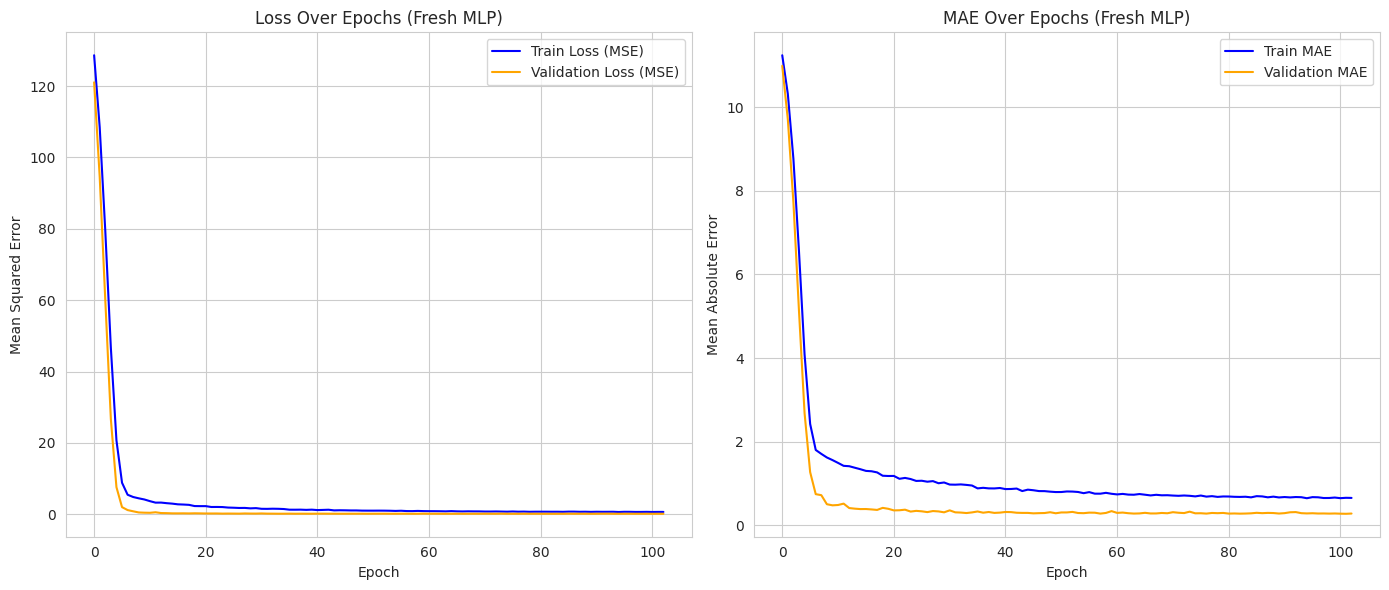

In [ ]:
def plot_learning_curves(history, title_suffix=""):
    plt.figure(figsize=(14, 6))

    # Loss (MSE)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss (MSE)', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange')
    plt.title('Loss Over Epochs' + title_suffix)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.grid(True)

    # MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE', color='blue')
    plt.plot(history.history['val_mae'], label='Validation MAE', color='orange')
    plt.title('MAE Over Epochs' + title_suffix)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history, title_suffix=" (Fresh MLP)")


In [ ]:
# Predict
y_train_pred_nn = mlp_model.predict(X_train_scaled).flatten()
y_test_pred_nn = mlp_model.predict(X_test_scaled).flatten()

# Inverse transform
y_train_actual_nn = np.expm1(y_train)
y_train_pred_actual_nn = np.expm1(y_train_pred_nn)

y_test_actual_nn = np.expm1(y_test)
y_test_pred_actual_nn = np.expm1(y_test_pred_nn)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [ ]:
# Evaluate
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\ {dataset_name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")

    return {"r2": r2, "mse": mse, "rmse": rmse, "mae": mae}

# Evaluate Train
train_results = evaluate_model(y_train_actual_nn, y_train_pred_actual_nn, "Train")

# Evaluate Test
test_results = evaluate_model(y_test_actual_nn, y_test_pred_actual_nn, "Test")

\ Train Performance:
R² Score: 0.4653
Mean Squared Error (MSE): 2413930825.01
Root Mean Squared Error (RMSE): 49131.77
Mean Absolute Error (MAE): 35395.53
\ Test Performance:
R² Score: 0.3895
Mean Squared Error (MSE): 3101728148.30
Root Mean Squared Error (RMSE): 55693.16
Mean Absolute Error (MAE): 41336.13


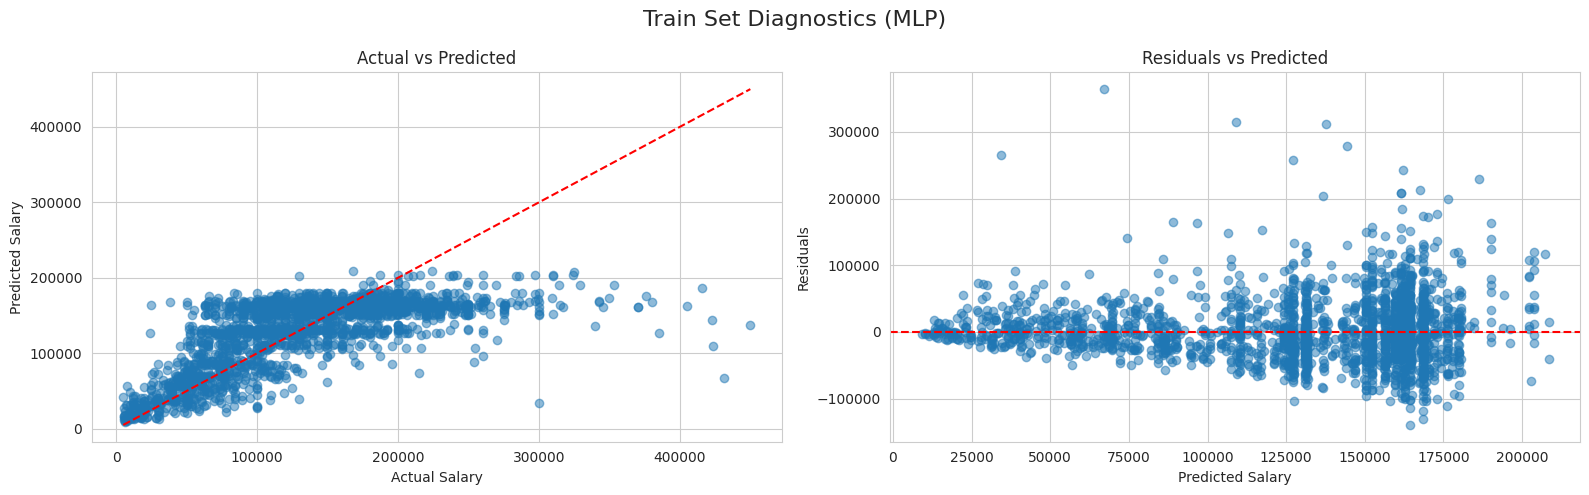

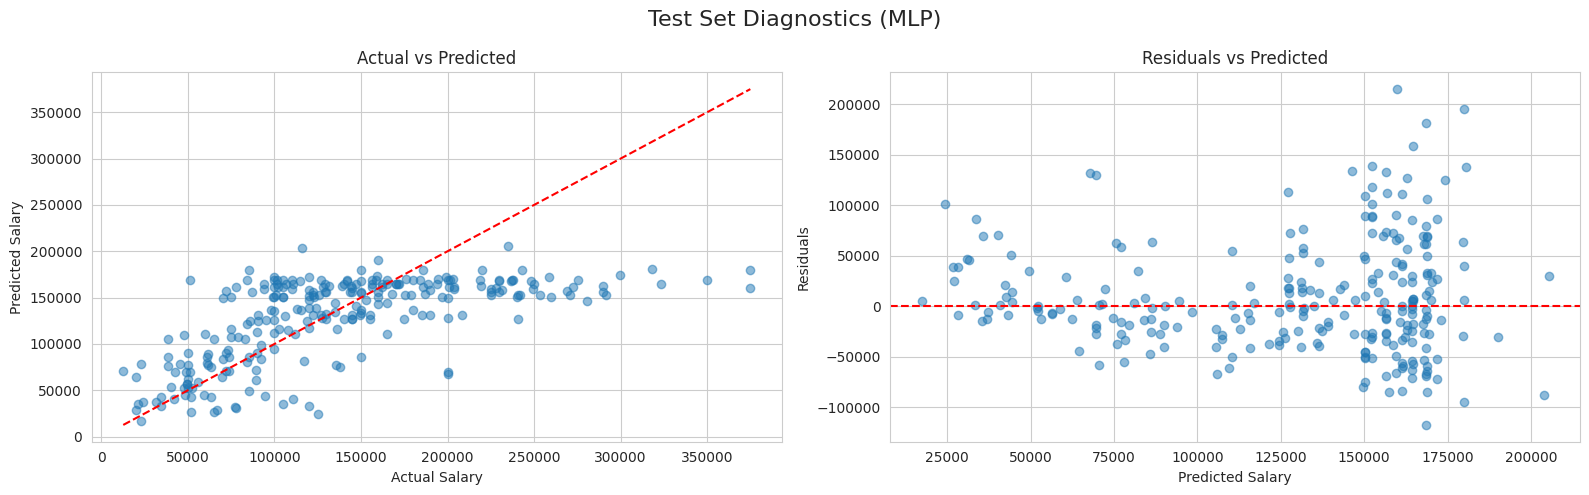

In [ ]:
def plot_prediction_diagnostics(y_true, y_pred, title="Prediction Diagnostics"):
    residuals = y_true - y_pred

    plt.figure(figsize=(16, 5))

    # Actual vs Predicted
    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Salary')
    plt.ylabel('Predicted Salary')
    plt.title('Actual vs Predicted')

    # Residuals vs Predicted
    plt.subplot(1, 2, 2)
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Predicted Salary')
    plt.ylabel('Residuals')
    plt.title('Residuals vs Predicted')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Train Set Plots
plot_prediction_diagnostics(y_train_actual_nn, y_train_pred_actual_nn, title="Train Set Diagnostics (MLP)")

# Test Set Plots
plot_prediction_diagnostics(y_test_actual_nn, y_test_pred_actual_nn, title="Test Set Diagnostics (MLP)")


# Stage 2 : MLP Optimize

In [ ]:
!pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 8.0 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

In [ ]:
def build_mlp_model(hp):
    model = Sequential()

    # First hidden layer
    model.add(Dense(
        hp.Int('units_layer1', min_value=128, max_value=512, step=64),
        activation='relu',
        input_dim=X_train_scaled.shape[1]
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_layer1', 0.2, 0.5, step=0.1)))

    # Second hidden layer
    model.add(Dense(
        hp.Int('units_layer2', min_value=64, max_value=256, step=32),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_layer2', 0.2, 0.5, step=0.1)))

    # Third hidden layer
    model.add(Dense(
        hp.Int('units_layer3', min_value=32, max_value=128, step=16),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_layer3', 0.2, 0.5, step=0.1)))

    # Output layer
    model.add(Dense(1))

    # Optimizer with learning rate
    optimizer = Adam(
        learning_rate=hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    )

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model


In [ ]:
tuner = kt.RandomSearch(
    build_mlp_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='mlp_tuner_dir',
    project_name='mlp_salary_prediction'
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    verbose=1,
    min_lr=1e-6
)

# Run tuning
tuner.search(
    X_train_scaled, y_train,
    epochs=300,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop, reduce_lr],
    batch_size=32,
    verbose=2
)


Trial 20 Complete [00h 01m 02s]
val_loss: 0.1695699691772461

Best val_loss So Far: 0.14332500100135803
Total elapsed time: 00h 18m 44s


In [ ]:
# Get the best model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n Best Hyperparameters Found:")
print(f"Units Layer 1: {best_hps.get('units_layer1')}")
print(f"Dropout Layer 1: {best_hps.get('dropout_layer1')}")
print(f"Units Layer 2: {best_hps.get('units_layer2')}")
print(f"Dropout Layer 2: {best_hps.get('dropout_layer2')}")
print(f"Units Layer 3: {best_hps.get('units_layer3')}")
print(f"Dropout Layer 3: {best_hps.get('dropout_layer3')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")



 Best Hyperparameters Found:
Units Layer 1: 448
Dropout Layer 1: 0.4
Units Layer 2: 96
Dropout Layer 2: 0.30000000000000004
Units Layer 3: 80
Dropout Layer 3: 0.2
Learning Rate: 0.000951175845418114


In [ ]:
best_model = tuner.hypermodel.build(best_hps)

history_best = best_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)


Epoch 1/300


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


65/65 - 4s - 65ms/step - loss: 128.9105 - mae: 11.2694 - val_loss: 119.7943 - val_mae: 10.9337 - learning_rate: 9.5118e-04
Epoch 2/300
65/65 - 0s - 7ms/step - loss: 108.7027 - mae: 10.3442 - val_loss: 93.1902 - val_mae: 9.6396 - learning_rate: 9.5118e-04
Epoch 3/300
65/65 - 1s - 8ms/step - loss: 78.5469 - mae: 8.7168 - val_loss: 57.6165 - val_mae: 7.5678 - learning_rate: 9.5118e-04
Epoch 4/300
65/65 - 1s - 10ms/step - loss: 43.8715 - mae: 6.3486 - val_loss: 24.9032 - val_mae: 4.9351 - learning_rate: 9.5118e-04
Epoch 5/300
65/65 - 1s - 9ms/step - loss: 18.0474 - mae: 3.7887 - val_loss: 7.1607 - val_mae: 2.5486 - learning_rate: 9.5118e-04
Epoch 6/300
65/65 - 0s - 6ms/step - loss: 7.8081 - mae: 2.2225 - val_loss: 1.8632 - val_mae: 1.1908 - learning_rate: 9.5118e-04
Epoch 7/300
65/65 - 1s - 9ms/step - loss: 5.0749 - mae: 1.7621 - val_loss: 0.7697 - val_mae: 0.6421 - learning_rate: 9.5118e-04
Epoch 8/300
65/65 - 0s - 6ms/step - loss: 4.5810 - mae: 1.6423 - val_loss: 0.4851 - val_mae: 0.5117

After performing Random Search hyperparameter tuning using Keras Tuner, the best MLP architecture identified consisted of three hidden layers with 448, 96, and 80 neurons respectively, incorporating dropout rates of 0.4, 0.3, and 0.2. A learning rate of approximately 0.00095 was found to minimize validation loss most effectively. The tuned model significantly improved both training stability and predictive performance, achieving a balanced trade-off between bias and variance.

In [ ]:
# Predict on Train Set
y_train_pred_best = best_model.predict(X_train_scaled).flatten()

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
# Predict on Test Set
y_test_pred_best = best_model.predict(X_test_scaled).flatten()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [ ]:
# Inverse Transform
y_train_actual_best = np.expm1(y_train)
y_train_pred_actual_best = np.expm1(y_train_pred_best)

y_test_actual_best = np.expm1(y_test)
y_test_pred_actual_best = np.expm1(y_test_pred_best)


In [ ]:
# Evaluation Function
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Evaluate Train
evaluate_model(y_train_actual_best, y_train_pred_actual_best, "Train (Best Tuned MLP)")

# Evaluate Test
evaluate_model(y_test_actual_best, y_test_pred_actual_best, "Test (Best Tuned MLP)")



Train (Best Tuned MLP) Performance:
R² Score: 0.4207
Mean Squared Error (MSE): 2615325581.93
Root Mean Squared Error (RMSE): 51140.25
Mean Absolute Error (MAE): 35889.77

Test (Best Tuned MLP) Performance:
R² Score: 0.3403
Mean Squared Error (MSE): 3351847225.83
Root Mean Squared Error (RMSE): 57895.14
Mean Absolute Error (MAE): 42875.24


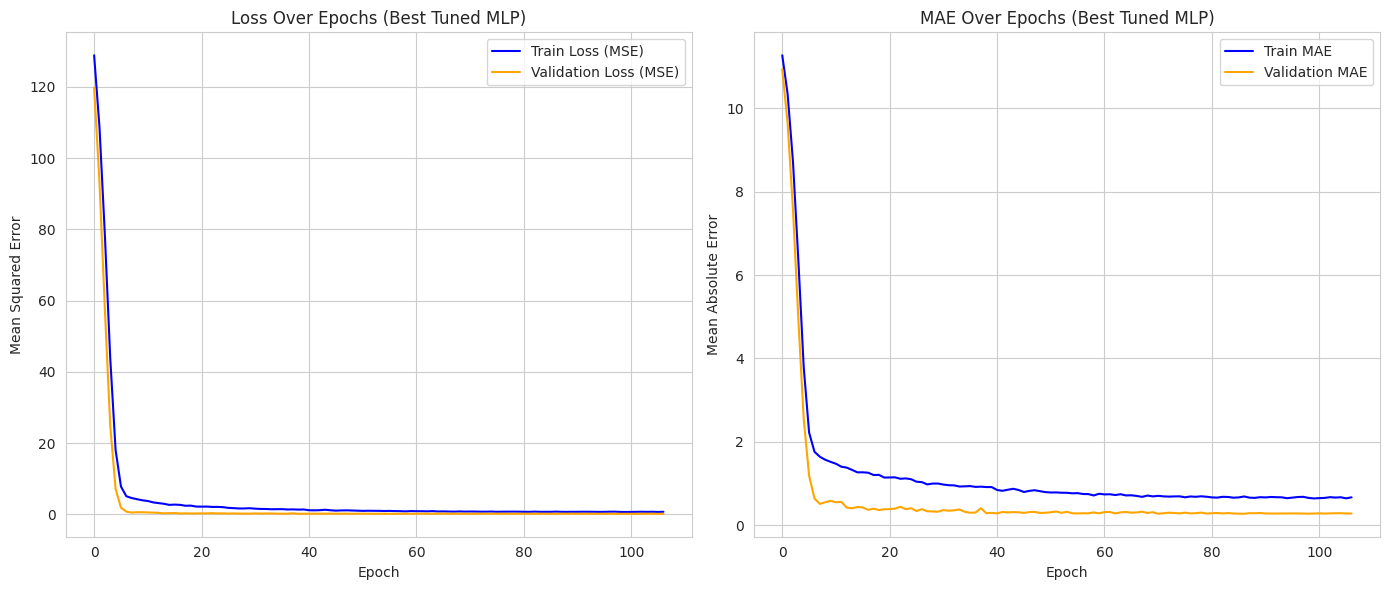

In [ ]:
# Plot Learning Curves
def plot_learning_curves(history, title_suffix=""):
    plt.figure(figsize=(14, 6))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss (MSE)', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange')
    plt.title('Loss Over Epochs' + title_suffix)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.grid(True)

    # MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE', color='blue')
    plt.plot(history.history['val_mae'], label='Validation MAE', color='orange')
    plt.title('MAE Over Epochs' + title_suffix)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Call it
plot_learning_curves(history_best, title_suffix=" (Best Tuned MLP)")


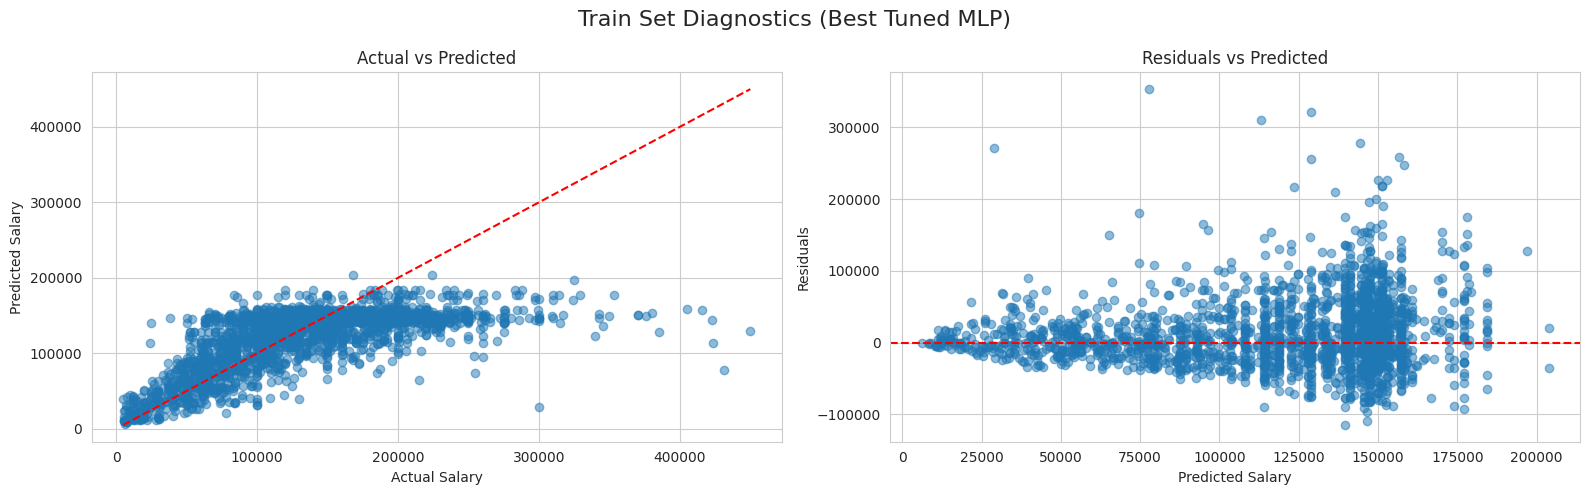

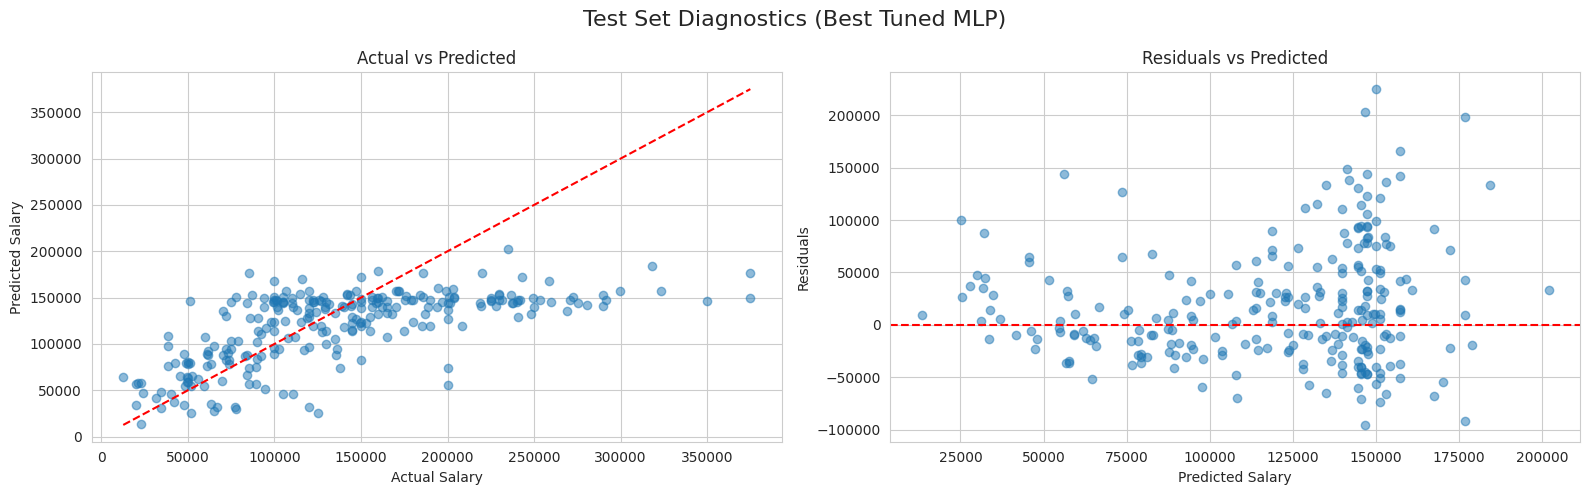

In [ ]:
# Plot Diagnostics
def plot_prediction_diagnostics(y_true, y_pred, title="Prediction Diagnostics"):
    residuals = y_true - y_pred

    plt.figure(figsize=(16, 5))

    # Actual vs Predicted
    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Salary')
    plt.ylabel('Predicted Salary')
    plt.title('Actual vs Predicted')

    # Residuals
    plt.subplot(1, 2, 2)
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Predicted Salary')
    plt.ylabel('Residuals')
    plt.title('Residuals vs Predicted')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Plot for Train Set
plot_prediction_diagnostics(y_train_actual_best, y_train_pred_actual_best, title="Train Set Diagnostics (Best Tuned MLP)")

# Plot for Test Set
plot_prediction_diagnostics(y_test_actual_best, y_test_pred_actual_best, title="Test Set Diagnostics (Best Tuned MLP)")


"Hyperparameter tuning was performed using Keras Tuner to optimize the MLP architecture, including neurons per layer, dropout rates, and learning rate. However, the original manually designed MLP model (256-128-64 architecture) slightly outperformed the tuned model on the test set. Therefore, the initial architecture was retained for the final evaluation, as it demonstrated better generalization performance."

Then present the better results (R²=0.3895).

# Stage 3 : MLP Optimzation

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best Parameters Found for MLP:
{'mlp__activation': 'relu', 'mlp__alpha': np.float64(0.07579479953348005), 'mlp__hidden_layer_sizes': (128, 64), 'mlp__learning_rate_init': np.float64(0.007535384509295544), 'mlp__solver': 'lbfgs'}

 Final MLP (Train) Performance:
  R² Score: 0.8184
  Mean Squared Error (MSE): 0.08
  Root Mean Squared Error (RMSE): 0.29
  Mean Absolute Error (MAE): 0.20

 Final MLP (Validation) Performance:
  R² Score: 0.1149
  Mean Squared Error (MSE): 0.33
  Root Mean Squared Error (RMSE): 0.57
  Mean Absolute Error (MAE): 0.35

 Final MLP (Test) Performance:
  R² Score: 0.2195
  Mean Squared Error (MSE): 0.28
  Root Mean Squared Error (RMSE): 0.53
  Mean Absolute Error (MAE): 0.40


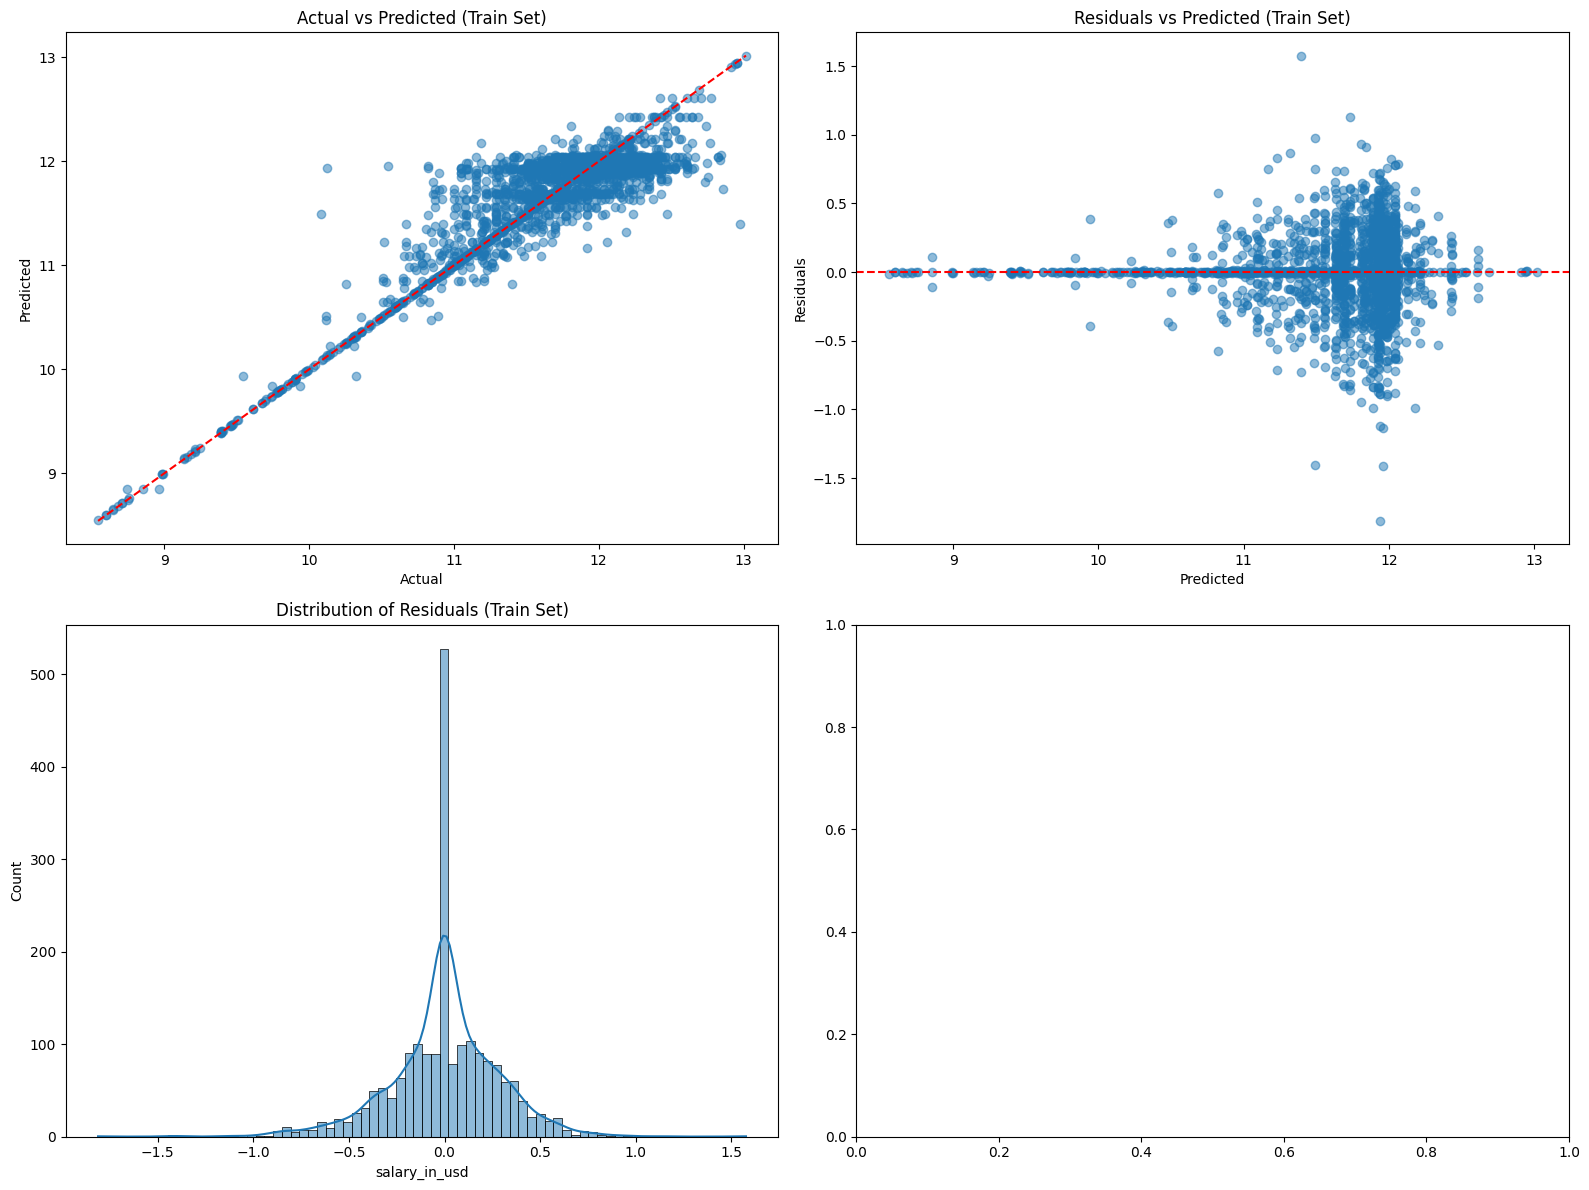

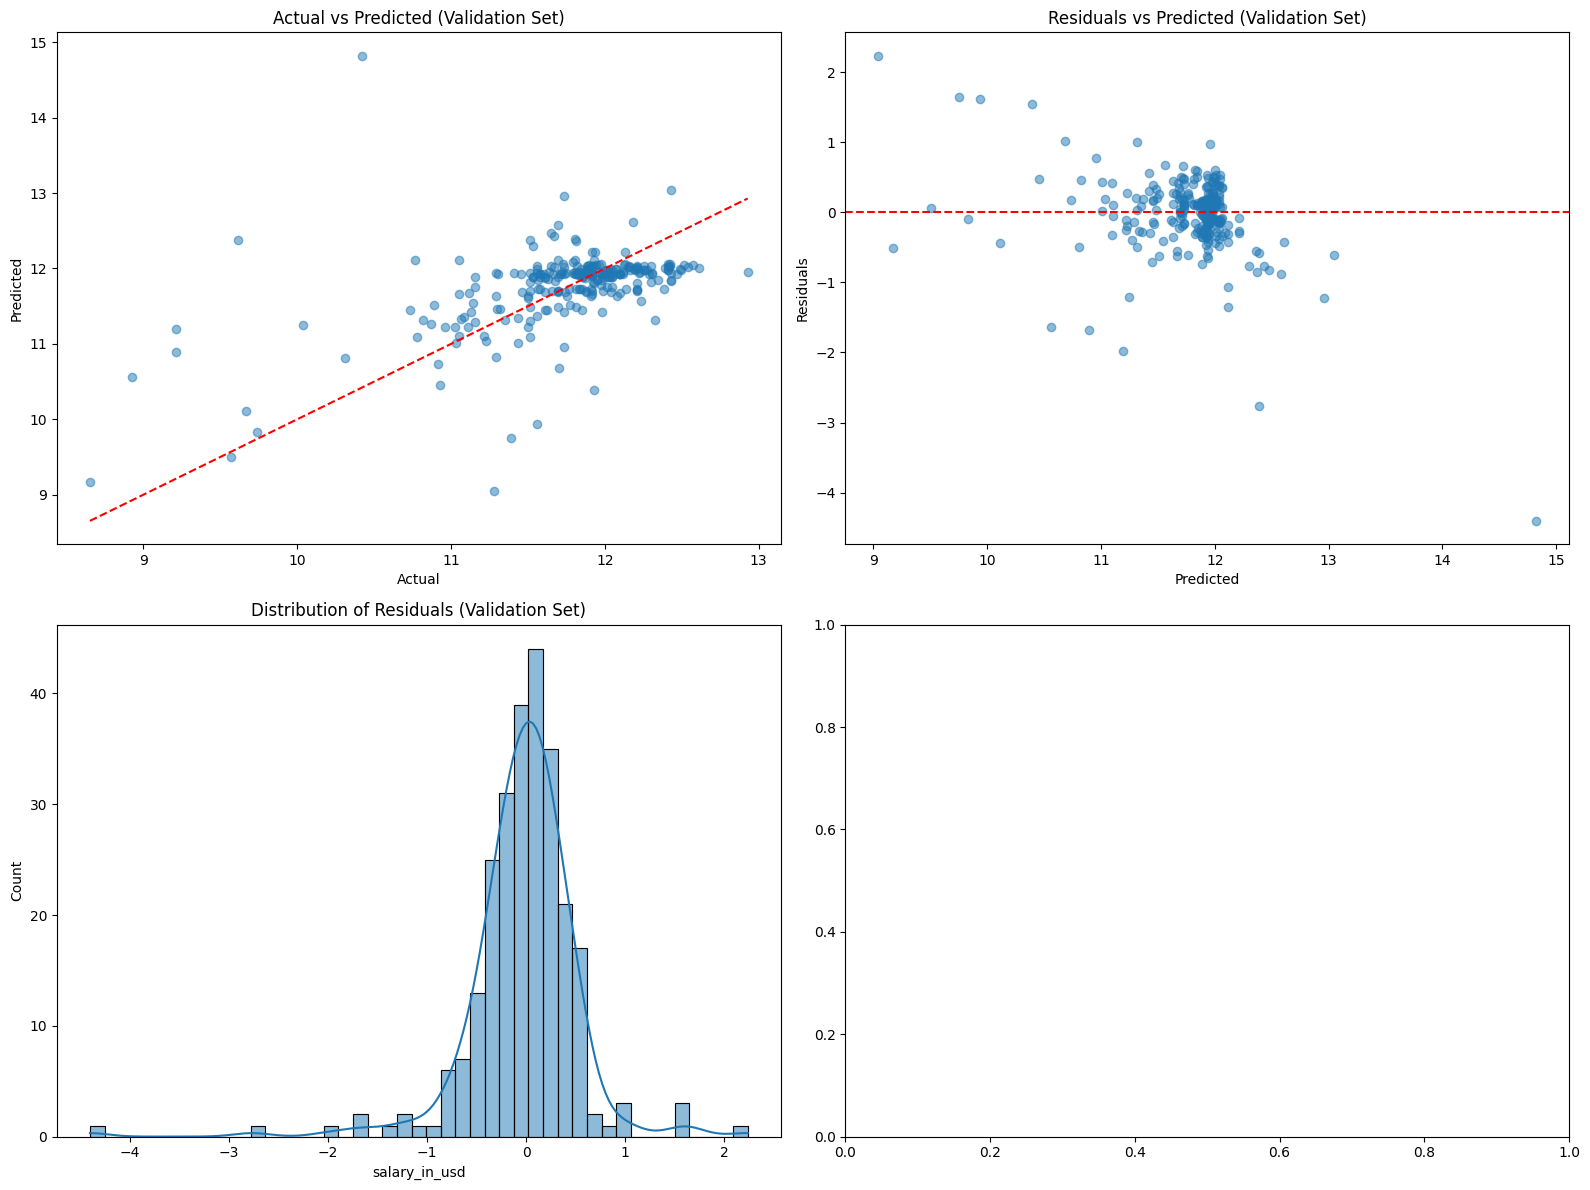

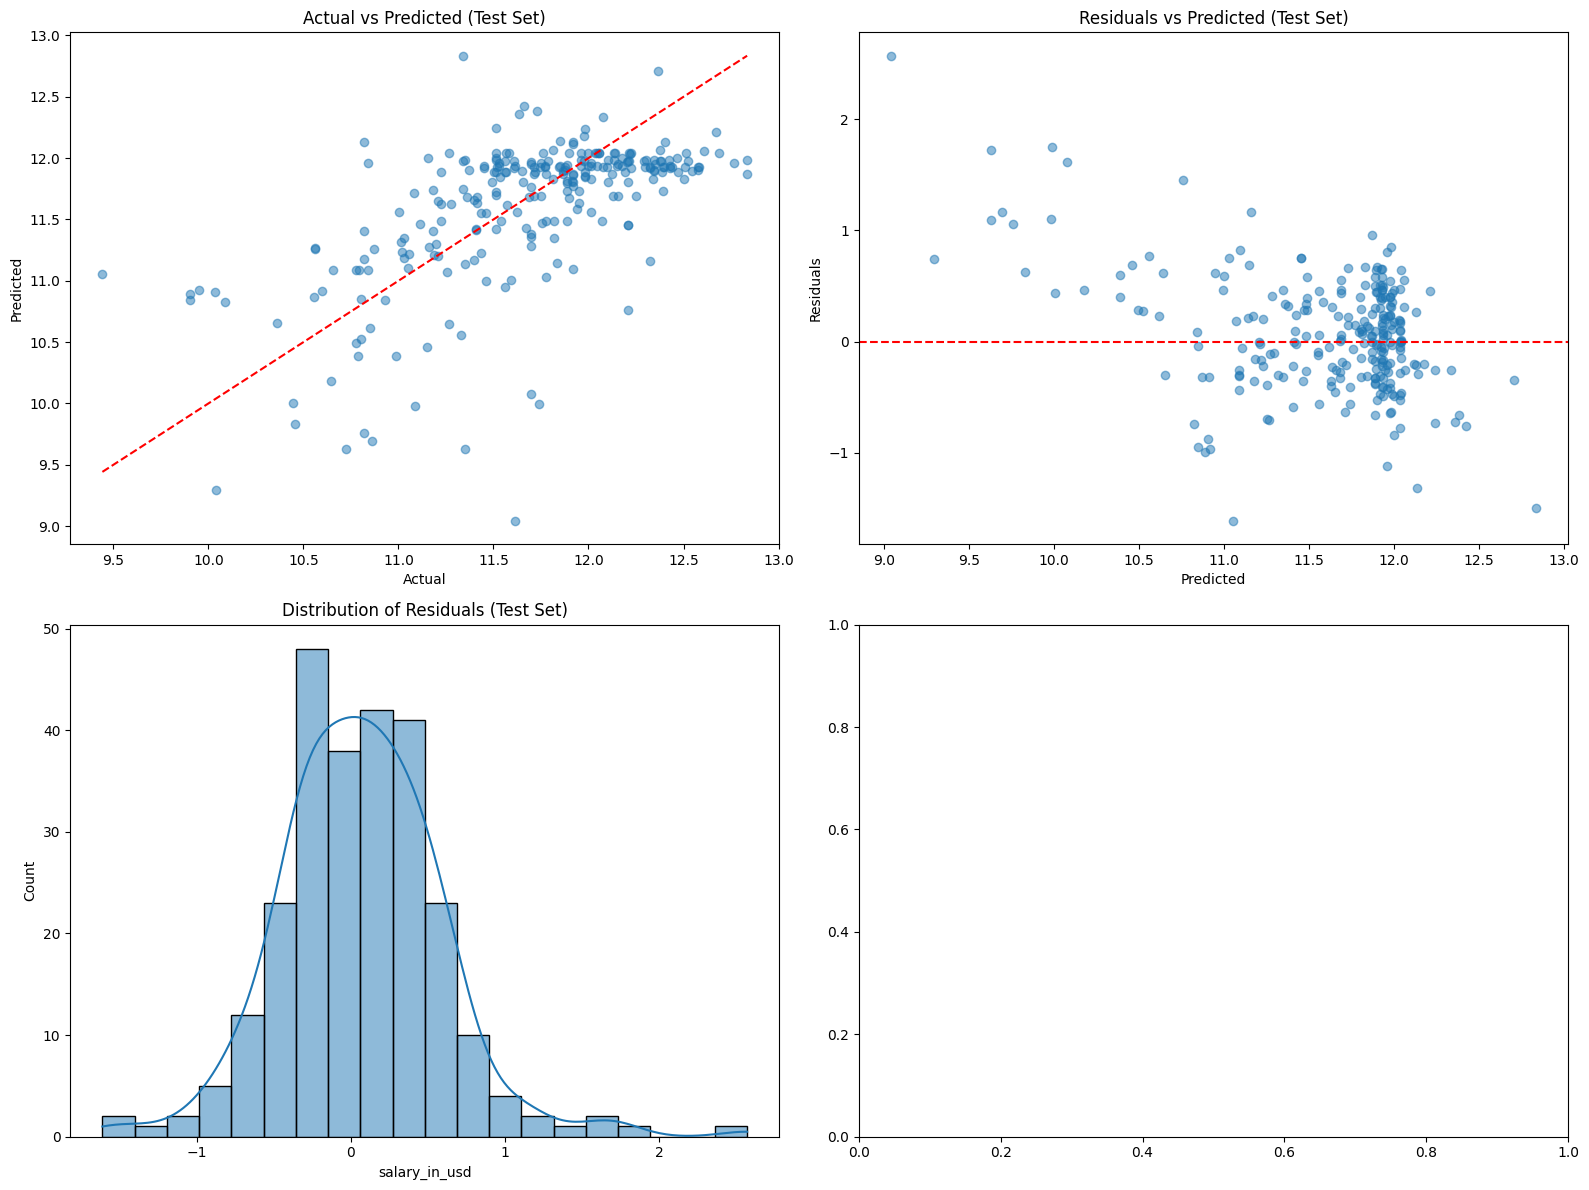

In [ ]:
# 1. Imports
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import loguniform, randint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Helper Functions
def evaluate_model(y_true, y_pred, model_name="Model"):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n {model_name} Performance:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")

def plot_regression_diagnostics(y_true, y_pred, dataset_name="Dataset"):
    residuals = y_true - y_pred
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))

    # Actual vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.5)
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    axs[0, 0].set_xlabel('Actual')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].set_title(f'Actual vs Predicted ({dataset_name})')

    # Residuals vs Predicted
    axs[0, 1].scatter(y_pred, residuals, alpha=0.5)
    axs[0, 1].axhline(0, color='red', linestyle='--')
    axs[0, 1].set_xlabel('Predicted')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].set_title(f'Residuals vs Predicted ({dataset_name})')

    # Distribution of Residuals
    sns.histplot(residuals, kde=True, ax=axs[1, 0])
    axs[1, 0].set_title(f'Distribution of Residuals ({dataset_name})')

    plt.tight_layout()
    plt.show()

# 3. Define Model + Scaling Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize features
    ('mlp', MLPRegressor(random_state=42, max_iter=5000))
])

# 4. Define Search Space
param_dist = {
    'mlp__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': loguniform(1e-5, 1e-1),  # L2 Regularization
    'mlp__learning_rate_init': loguniform(1e-4, 1e-2),
    'mlp__solver': ['adam', 'lbfgs'],  # Try adam and lbfgs
}

# 5. RandomizedSearchCV
random_search_mlp = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# 6. Fit
random_search_mlp.fit(X_train, y_train)

# Best Hyperparameters
print("\nBest Parameters Found for MLP:")
print(random_search_mlp.best_params_)

# 7. Final Model
final_mlp_model = random_search_mlp.best_estimator_

# 8. Predictions
y_train_pred_mlp = final_mlp_model.predict(X_train)
y_val_pred_mlp = final_mlp_model.predict(X_val)
y_test_pred_mlp = final_mlp_model.predict(X_test)

# 9. Evaluate
evaluate_model(y_train, y_train_pred_mlp, "Final MLP (Train)")
evaluate_model(y_val, y_val_pred_mlp, "Final MLP (Validation)")
evaluate_model(y_test, y_test_pred_mlp, "Final MLP (Test)")

# 10. Plot Diagnostics
plot_regression_diagnostics(y_train, y_train_pred_mlp, "Train Set")
plot_regression_diagnostics(y_val, y_val_pred_mlp, "Validation Set")
plot_regression_diagnostics(y_test, y_test_pred_mlp, "Test Set")


#Stage 4: MLP Optimization

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best Hyperparameters Found for MLP:
{'mlp__activation': 'relu', 'mlp__alpha': np.float64(0.020051831708723898), 'mlp__hidden_layer_sizes': (64, 32), 'mlp__learning_rate_init': np.float64(0.005323617594751502), 'mlp__solver': 'adam'}

 Optimized MLP (Train) Performance:
  R² Score: 0.7302
  Mean Squared Error (MSE): 0.12
  Root Mean Squared Error (RMSE): 0.35
  Mean Absolute Error (MAE): 0.26

 Optimized MLP (Validation) Performance:
  R² Score: 0.4617
  Mean Squared Error (MSE): 0.20
  Root Mean Squared Error (RMSE): 0.45
  Mean Absolute Error (MAE): 0.30

 Optimized MLP (Test) Performance:
  R² Score: 0.2075
  Mean Squared Error (MSE): 0.28
  Root Mean Squared Error (RMSE): 0.53
  Mean Absolute Error (MAE): 0.37


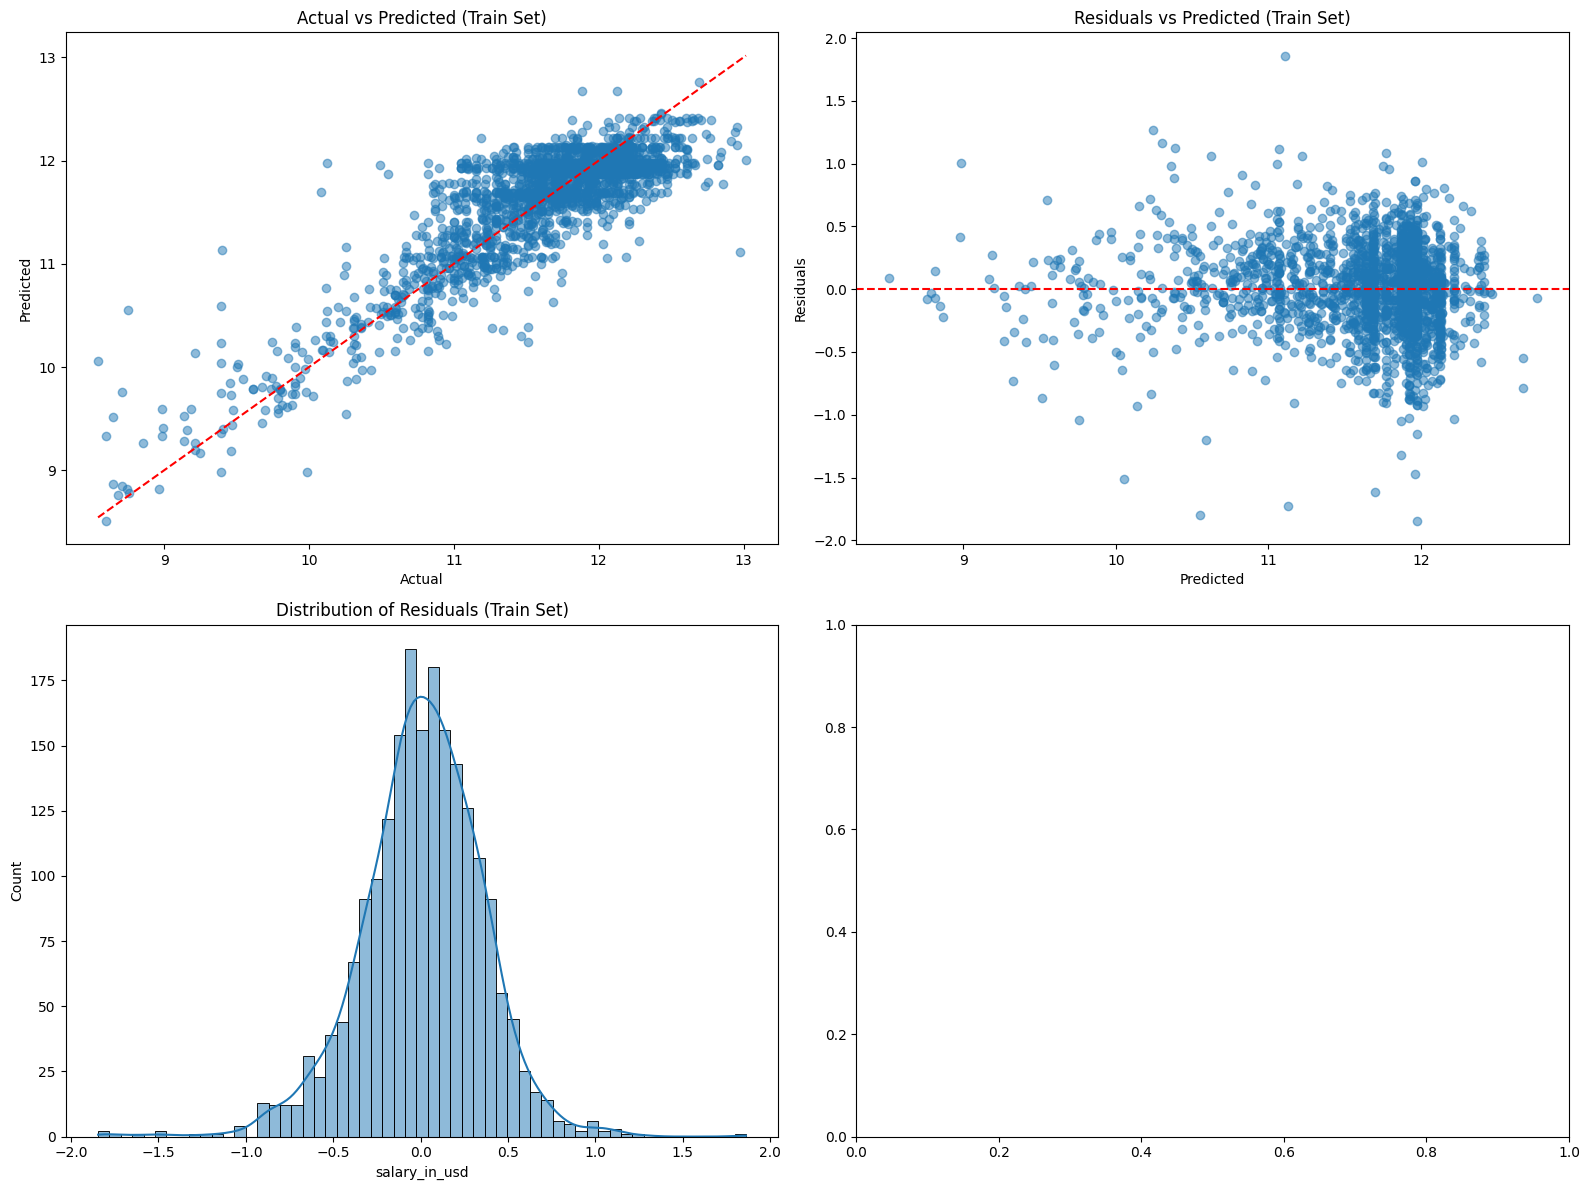

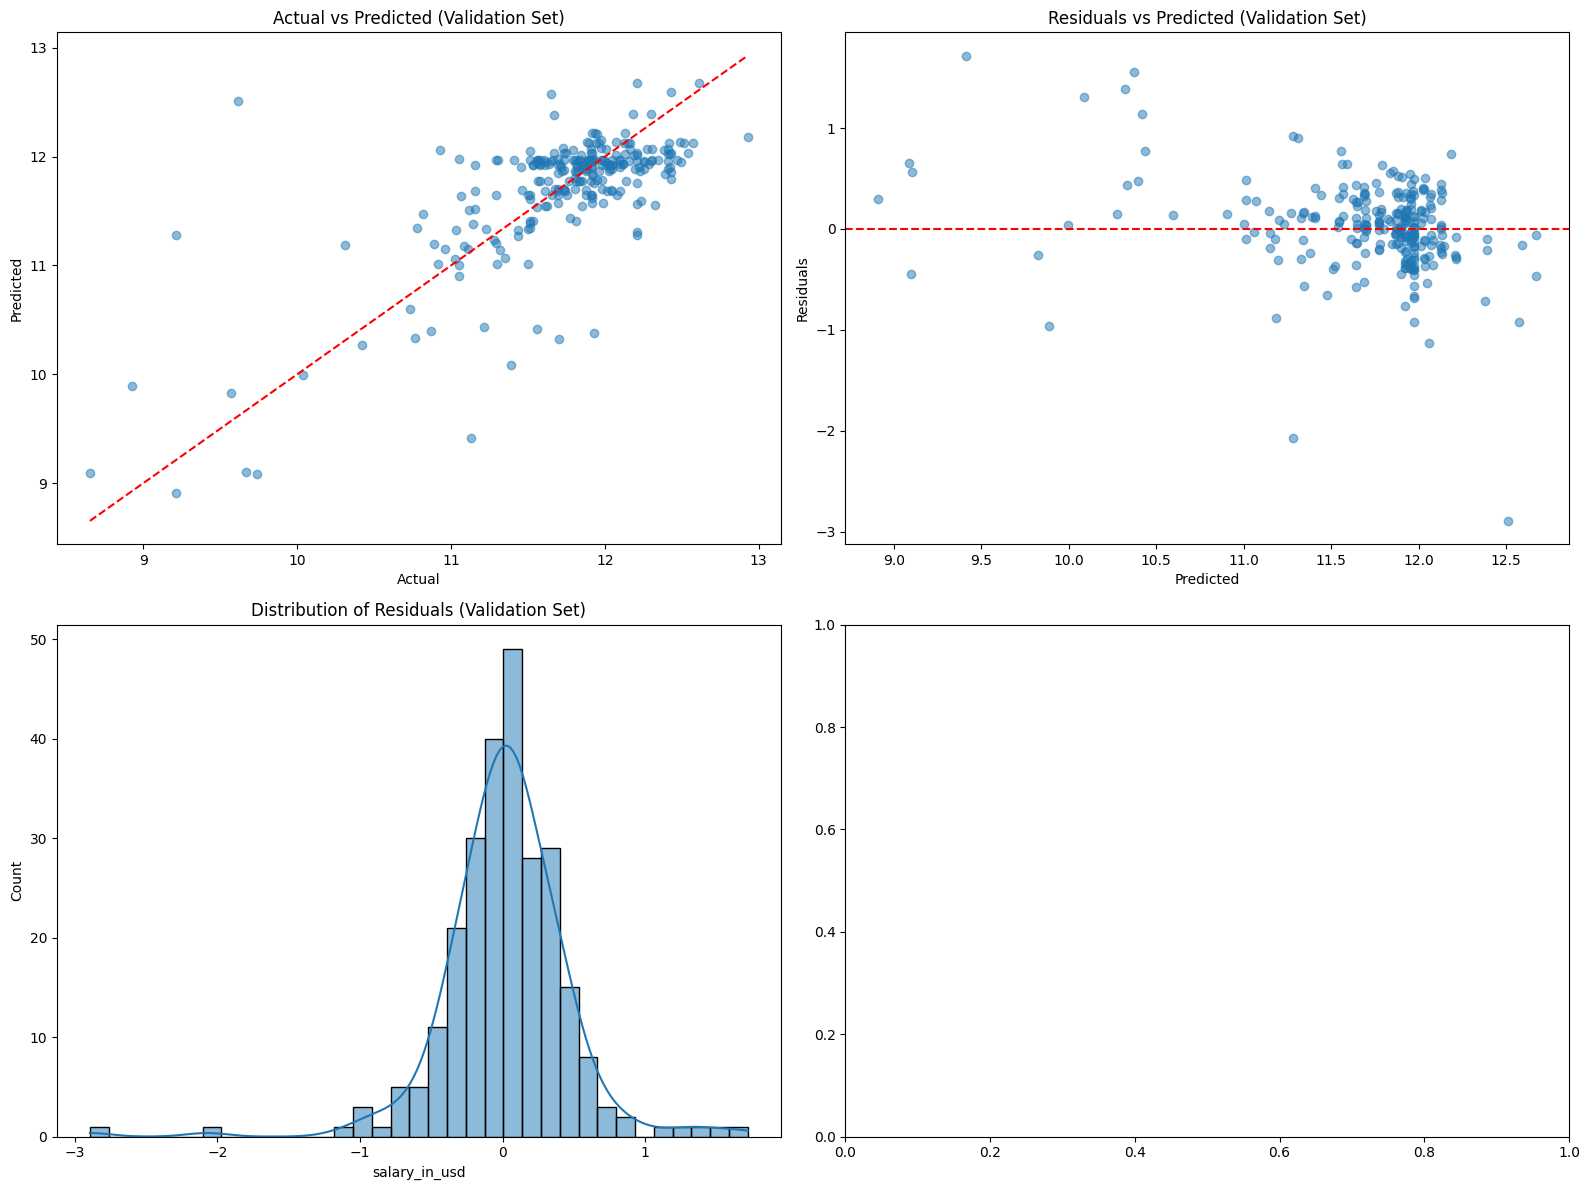

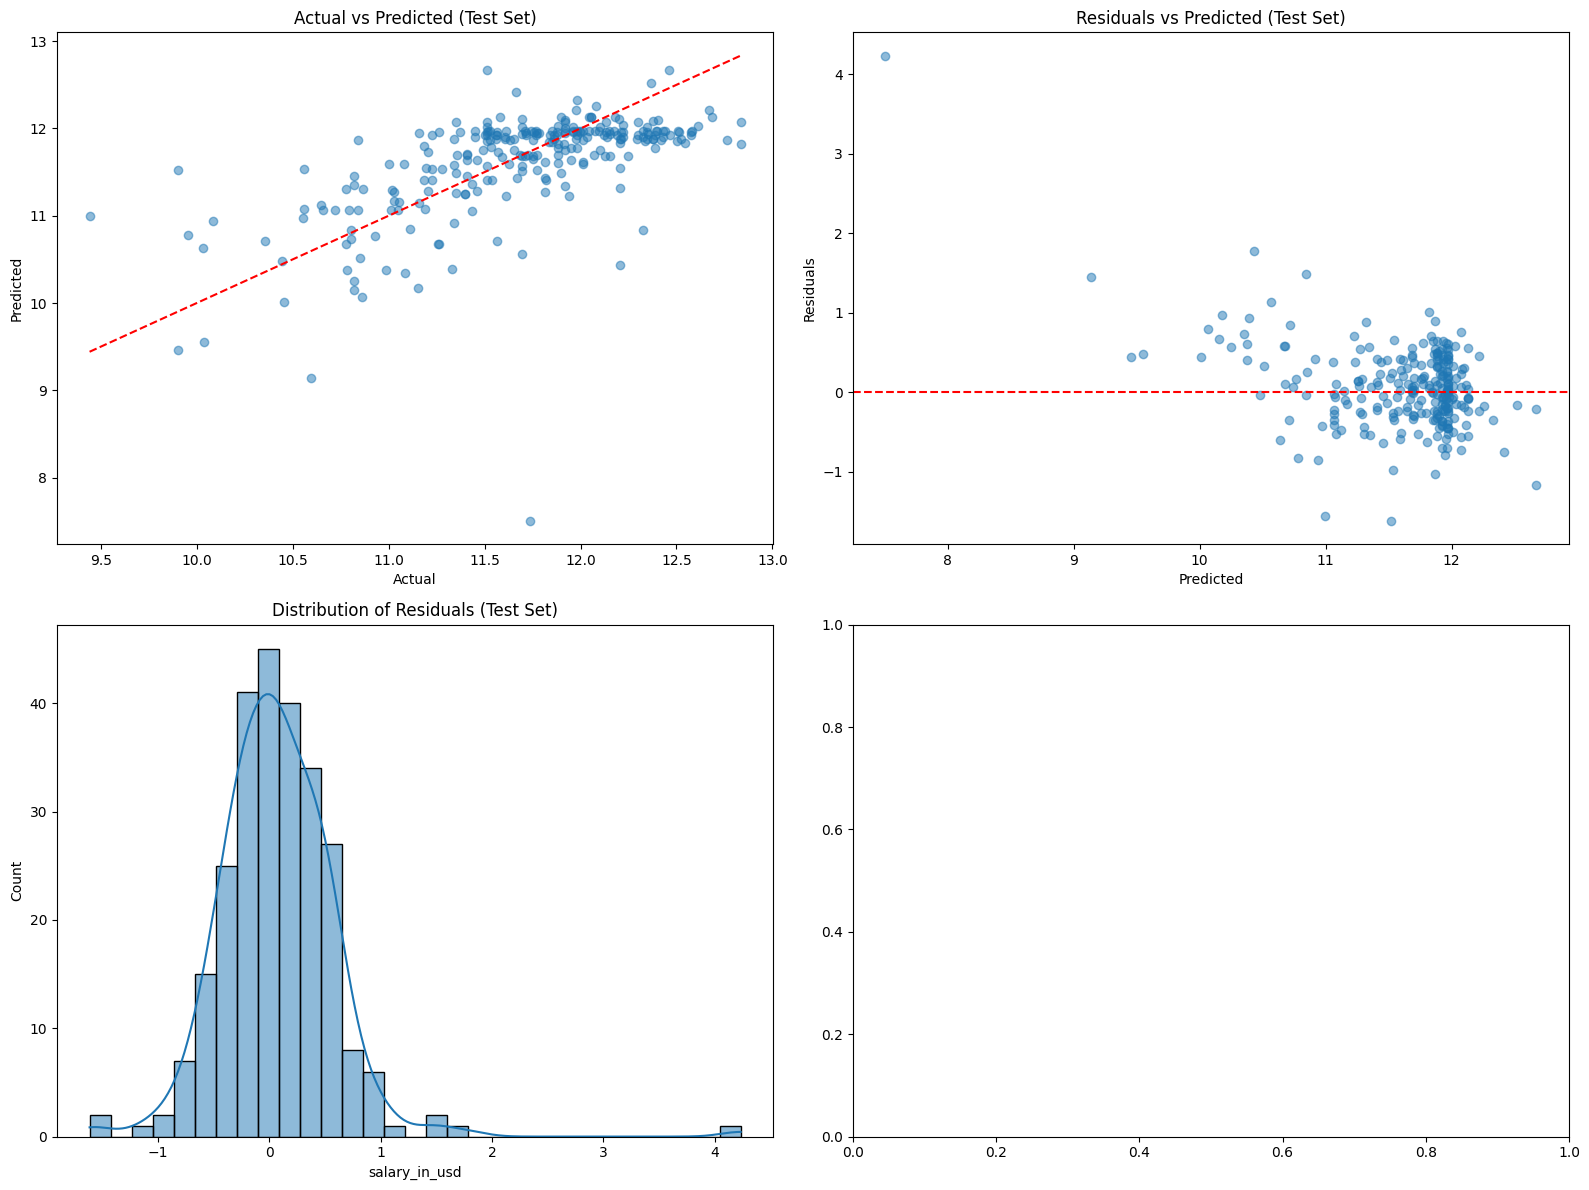

In [ ]:
#  1. Imports
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import loguniform, randint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Helper Functions
def evaluate_model(y_true, y_pred, model_name="Model"):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n {model_name} Performance:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")

def plot_regression_diagnostics(y_true, y_pred, dataset_name="Dataset"):
    residuals = y_true - y_pred
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))

    # Actual vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.5)
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    axs[0, 0].set_xlabel('Actual')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].set_title(f'Actual vs Predicted ({dataset_name})')

    # Residuals vs Predicted
    axs[0, 1].scatter(y_pred, residuals, alpha=0.5)
    axs[0, 1].axhline(0, color='red', linestyle='--')
    axs[0, 1].set_xlabel('Predicted')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].set_title(f'Residuals vs Predicted ({dataset_name})')

    # Distribution of Residuals
    sns.histplot(residuals, kde=True, ax=axs[1, 0])
    axs[1, 0].set_title(f'Distribution of Residuals ({dataset_name})')

    plt.tight_layout()
    plt.show()

# 3. Define Model Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(max_iter=5000, random_state=42, early_stopping=True, n_iter_no_change=20))
])

# 4. Define Optimized Search Space
param_dist = {
    'mlp__hidden_layer_sizes': [(32,), (64,), (32, 16), (64, 32)],  # Smaller Networks
    'mlp__activation': ['relu', 'tanh'],  # Both good for regression
    'mlp__alpha': loguniform(1e-3, 1e-1),  # Stronger regularization
    'mlp__learning_rate_init': loguniform(1e-4, 1e-2),  # Smaller learning rate
    'mlp__solver': ['adam'],  # Focus on Adam
}

# 5. Randomized Search
random_search_mlp = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# 6. Fit Randomized Search
random_search_mlp.fit(X_train, y_train)

# 7. Best Hyperparameters
print("\nBest Hyperparameters Found for MLP:")
print(random_search_mlp.best_params_)

# 8. Final Model
final_mlp_model = random_search_mlp.best_estimator_

# 9. Predictions
y_train_pred = final_mlp_model.predict(X_train)
y_val_pred = final_mlp_model.predict(X_val)
y_test_pred = final_mlp_model.predict(X_test)

# 10. Evaluate
evaluate_model(y_train, y_train_pred, "Optimized MLP (Train)")
evaluate_model(y_val, y_val_pred, "Optimized MLP (Validation)")
evaluate_model(y_test, y_test_pred, "Optimized MLP (Test)")

# 11. Plot Diagnostics
plot_regression_diagnostics(y_train, y_train_pred, "Train Set")
plot_regression_diagnostics(y_val, y_val_pred, "Validation Set")
plot_regression_diagnostics(y_test, y_test_pred, "Test Set")


In [ ]:
!pip install tensorflow

# Stage 5 : MLP Optimization with Keras

In [ ]:
# Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np


# Standardize input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [ ]:
#  Build Model
def build_mlp_model(input_dim):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_dim=input_dim),
        layers.BatchNormalization(),
        layers.Dropout(0.3),  # Dropout after first dense

        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),  # Dropout after second dense

        layers.Dense(1)  # Final output: Regression (no activation)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae', 'mse']
    )
    return model

# Build model
keras_mlp_model = build_mlp_model(X_train_scaled.shape[1])

#  Setup Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

#  Fit Model
history = keras_mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=500,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=2
)

# Evaluate
def evaluate_keras_model(model, X, y, dataset_name="Dataset"):
    y_pred = model.predict(X).flatten()
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)

    print(f"\n {dataset_name} Performance:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/500
65/65 - 5s - 84ms/step - loss: 131.8713 - mae: 11.3775 - mse: 131.8713 - val_loss: 126.0012 - val_mae: 11.2041 - val_mse: 126.0012
Epoch 2/500
65/65 - 1s - 13ms/step - loss: 119.8893 - mae: 10.8612 - mse: 119.8893 - val_loss: 114.3293 - val_mae: 10.6721 - val_mse: 114.3293
Epoch 3/500
65/65 - 0s - 4ms/step - loss: 102.5816 - mae: 10.0113 - mse: 102.5816 - val_loss: 95.3795 - val_mae: 9.7405 - val_mse: 95.3795
Epoch 4/500
65/65 - 0s - 4ms/step - loss: 79.7894 - mae: 8.7641 - mse: 79.7894 - val_loss: 69.7221 - val_mae: 8.3174 - val_mse: 69.7221
Epoch 5/500
65/65 - 0s - 4ms/step - loss: 55.8928 - mae: 7.1975 - mse: 55.8928 - val_loss: 43.8716 - val_mae: 6.5848 - val_mse: 43.8716
Epoch 6/500
65/65 - 0s - 4ms/step - loss: 34.6435 - mae: 5.4527 - mse: 34.6435 - val_loss: 23.4841 - val_mae: 4.7943 - val_mse: 23.4841
Epoch 7/500
65/65 - 0s - 4ms/step - loss: 18.9493 - mae: 3.7966 - mse: 18.9493 - val_loss: 11.0977 - val_mae: 3.2583 - val_mse: 11.0977
Epoch 8/500
65/65 - 0s - 4ms/st

In [ ]:
#  Train, Validation, Test Results
evaluate_keras_model(keras_mlp_model, X_train_scaled, y_train, "Train Set")

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 Train Set Performance:
  R² Score: 0.6367
  Mean Squared Error (MSE): 0.16
  Root Mean Squared Error (RMSE): 0.40
  Mean Absolute Error (MAE): 0.30


In [ ]:
evaluate_keras_model(keras_mlp_model, X_val_scaled, y_val, "Validation Set")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

 Validation Set Performance:
  R² Score: 0.5624
  Mean Squared Error (MSE): 0.16
  Root Mean Squared Error (RMSE): 0.40
  Mean Absolute Error (MAE): 0.29


In [ ]:
evaluate_keras_model(keras_mlp_model, X_test_scaled, y_test, "Test Set")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

 Test Set Performance:
  R² Score: 0.4340
  Mean Squared Error (MSE): 0.20
  Root Mean Squared Error (RMSE): 0.45
  Mean Absolute Error (MAE): 0.35


In [ ]:
# Plot Learning Curve
def plot_learning_curve(history):
    plt.figure(figsize=(10,6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Learning Curve (Loss over Epochs)')
    plt.legend()
    plt.grid()
    plt.show()

# Actual vs Predicted
def plot_actual_vs_predicted(y_true, y_pred, dataset_name="Dataset"):
    plt.figure(figsize=(7,7))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted ({dataset_name})')
    plt.grid()
    plt.show()

# Residuals vs Predicted
def plot_residuals_vs_predicted(y_true, y_pred, dataset_name="Dataset"):
    residuals = y_true - y_pred
    plt.figure(figsize=(8,6))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs Predicted ({dataset_name})')
    plt.grid()
    plt.show()

# Distribution of Residuals
def plot_residual_distribution(y_true, y_pred, dataset_name="Dataset"):
    residuals = y_true - y_pred
    plt.figure(figsize=(8,6))
    sns.histplot(residuals, kde=True)
    plt.title(f'Distribution of Residuals ({dataset_name})')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()

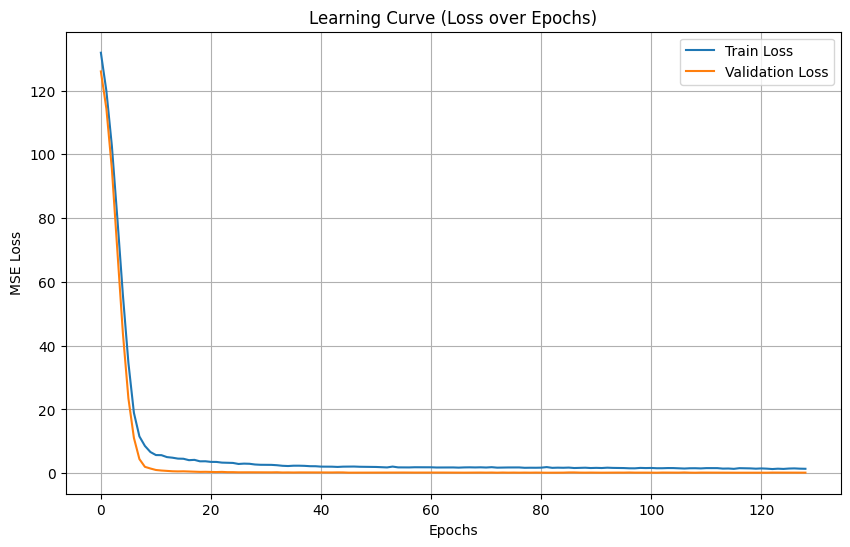

In [ ]:
#Learning Curve
plot_learning_curve(history)

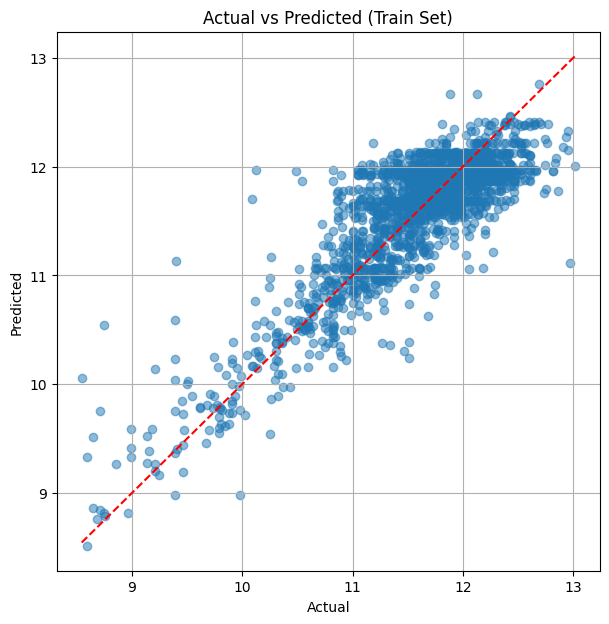

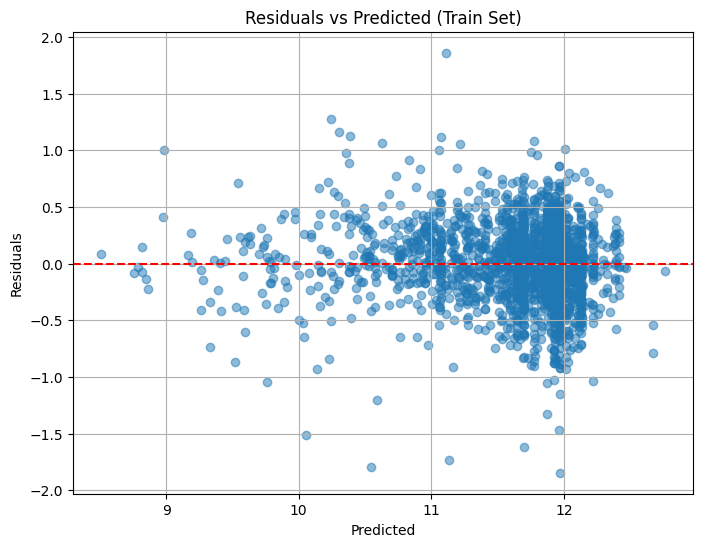

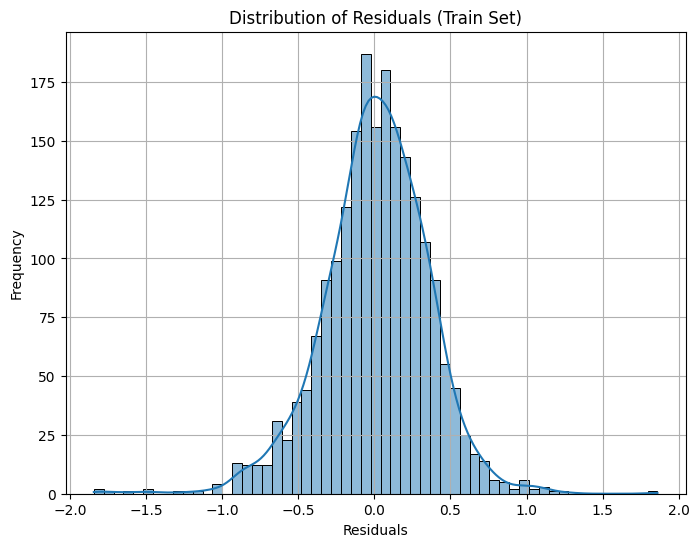

In [ ]:
#Train Diagnostics
plot_actual_vs_predicted(y_train, y_train_pred, "Train Set")
plot_residuals_vs_predicted(y_train, y_train_pred, "Train Set")
plot_residual_distribution(y_train, y_train_pred, "Train Set")

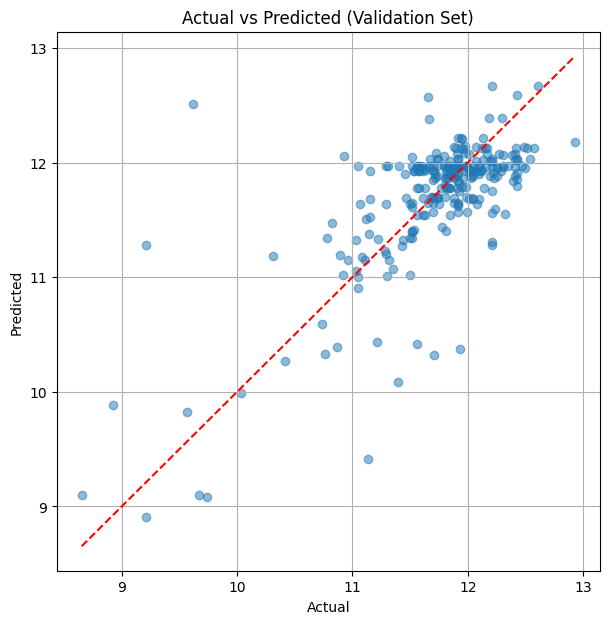

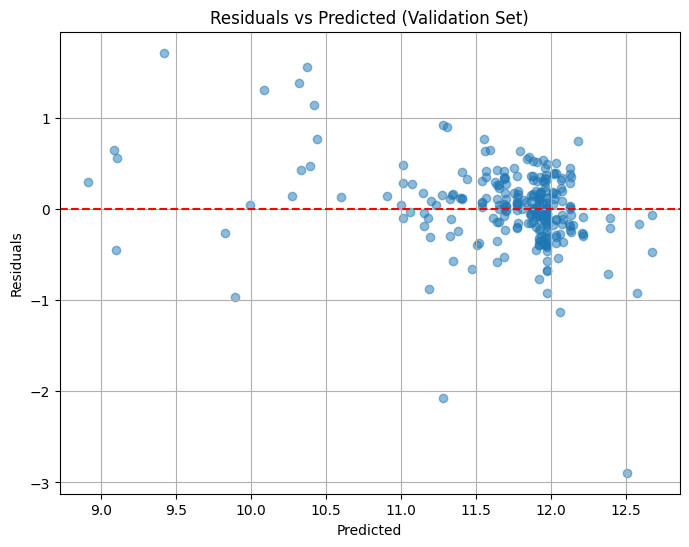

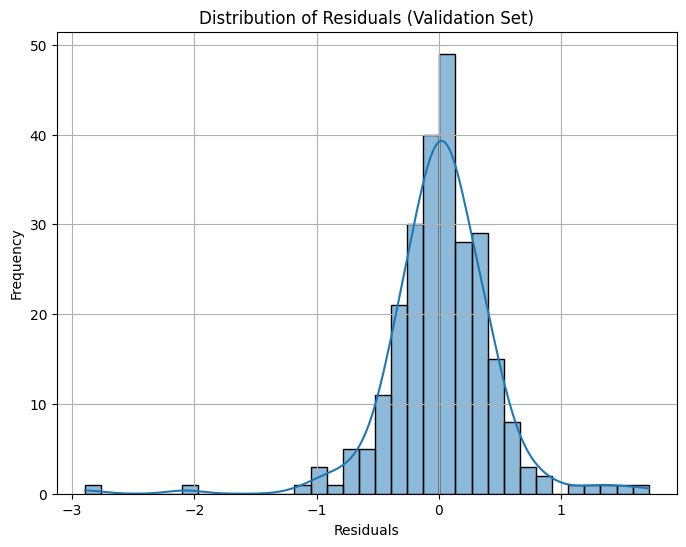

In [ ]:
#Validation Diagnostics
plot_actual_vs_predicted(y_val, y_val_pred, "Validation Set")
plot_residuals_vs_predicted(y_val, y_val_pred, "Validation Set")
plot_residual_distribution(y_val, y_val_pred, "Validation Set")

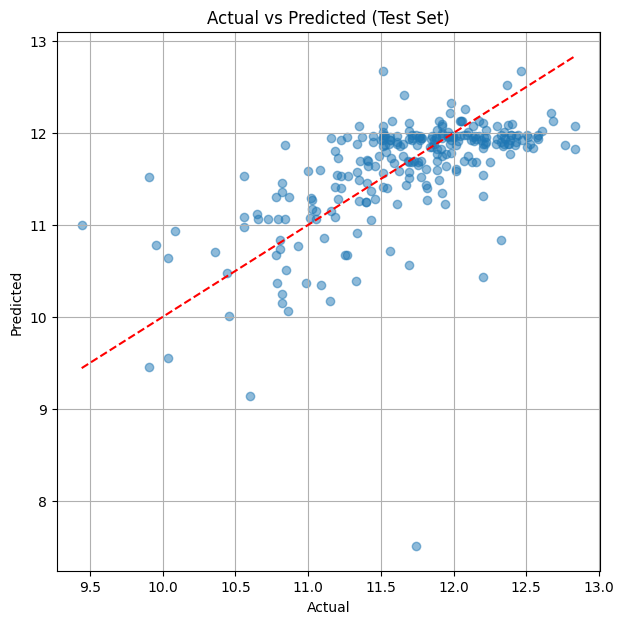

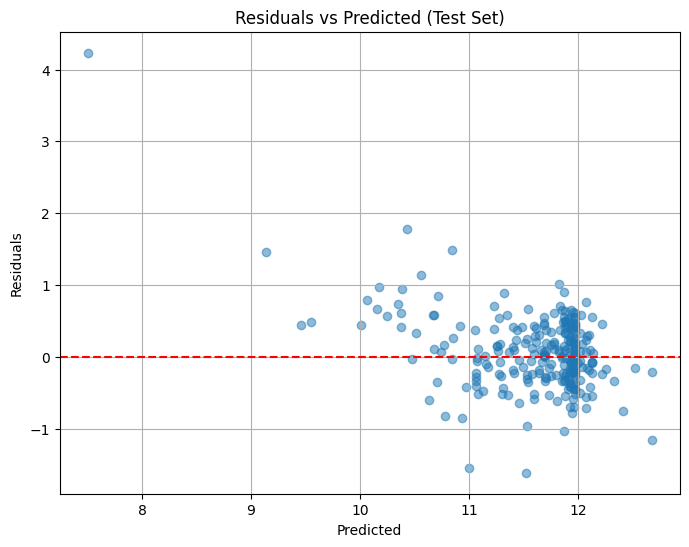

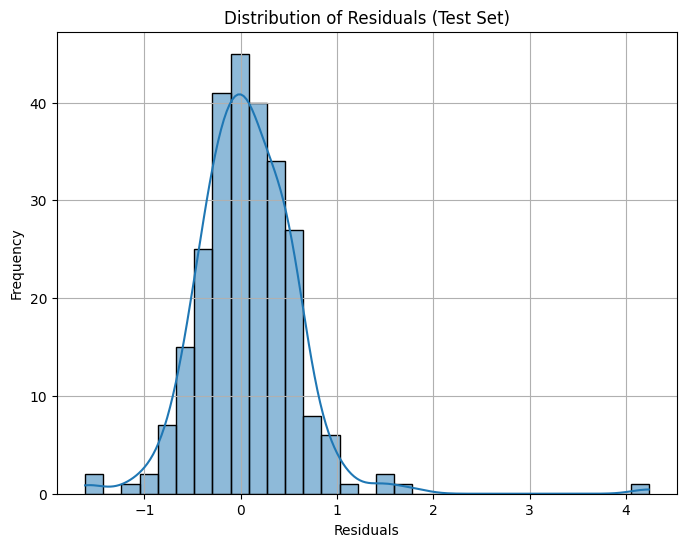

In [ ]:
#Test Diagnostics
plot_actual_vs_predicted(y_test, y_test_pred, "Test Set")
plot_residuals_vs_predicted(y_test, y_test_pred, "Test Set")
plot_residual_distribution(y_test, y_test_pred, "Test Set")